## 12. Feature Engineering

The purpose of this section is to transform the prepared daily analytical dataset into a modeling-ready dataset for demand forecasting.

Feature engineering creates time-based, sales-based, stockout-based, calendar-based, promotion-based, and weather-related variables that can help forecasting models learn historical demand behavior and product availability patterns.

The modeling dataset will be created at the same analytical grain used throughout the project:

`store_id + product_id + dt`

### 12.1 Load Prepared Training and Evaluation Data

The prepared training and evaluation files are loaded as the main input for feature engineering.

These files were already validated during the data quality assessment stage and confirmed to have consistent schema, complete product-store time series, and no duplicate product-store-date records.

In [1]:
import pandas as pd
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

daily_train = pd.read_csv(processed_folder / "freshretail_daily_train_prepared.csv")
daily_eval = pd.read_csv(processed_folder / "freshretail_daily_eval_prepared.csv")

daily_train["dt"] = pd.to_datetime(daily_train["dt"])
daily_eval["dt"] = pd.to_datetime(daily_eval["dt"])

daily_train = daily_train.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)
daily_eval = daily_eval.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

print("Train shape:", daily_train.shape)
print("Eval shape:", daily_eval.shape)

display(daily_train.head())

Train shape: (4500000, 17)
Eval shape: (350000, 17)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,2,29,78,82,4,2024-03-28,0.5,13,0.882,0,1,1.6999,15.48,73.54,1.97
1,0,0,2,29,78,82,4,2024-03-29,1.3,5,0.882,0,1,3.0190,15.08,76.56,1.71
2,0,0,2,29,78,82,4,2024-03-30,5.3,0,0.882,1,1,2.0942,15.91,76.47,1.73
3,0,0,2,29,78,82,4,2024-03-31,4.2,0,0.879,1,1,1.5618,16.13,77.40,1.76
4,0,0,2,29,78,82,4,2024-04-01,0.7,0,0.882,0,1,3.5386,15.37,78.26,1.25


### 12.2 Calendar Features

Calendar features are created from the `dt` column to help the forecasting model capture time-based demand patterns.

The EDA showed that demand differs by weekday, weekend, and holiday periods. Therefore, calendar features are important for modeling repeated demand patterns.

In [2]:
def add_calendar_features(df):
    df = df.copy()
    
    df["day_of_week"] = df["dt"].dt.dayofweek
    df["day_name"] = df["dt"].dt.day_name()
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["day_of_month"] = df["dt"].dt.day
    df["week_of_year"] = df["dt"].dt.isocalendar().week.astype(int)
    df["month"] = df["dt"].dt.month
    
    return df

daily_train = add_calendar_features(daily_train)
daily_eval = add_calendar_features(daily_eval)

display(daily_train[[
    "dt",
    "day_of_week",
    "day_name",
    "is_weekend",
    "day_of_month",
    "week_of_year",
    "month"
]].head())

,dt,day_of_week,day_name,is_weekend,day_of_month,week_of_year,month
0,2024-03-28,3,Thursday,0,28,13,3
1,2024-03-29,4,Friday,0,29,13,3
2,2024-03-30,5,Saturday,1,30,13,3
3,2024-03-31,6,Sunday,1,31,13,3
4,2024-04-01,0,Monday,0,1,14,4


### 12.3 Sales Lag Features

Lag features use previous sales values from the same product-store time series.

These features help the model learn recent demand behavior and weekly demand patterns.

The lag features created in this step are:

- `sales_lag_1`
- `sales_lag_7`
- `sales_lag_14`
- `sales_lag_28`

In [3]:
def add_sales_lag_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    df["sales_lag_1"] = df.groupby(group_cols)["sale_amount"].shift(1)
    df["sales_lag_7"] = df.groupby(group_cols)["sale_amount"].shift(7)
    df["sales_lag_14"] = df.groupby(group_cols)["sale_amount"].shift(14)
    df["sales_lag_28"] = df.groupby(group_cols)["sale_amount"].shift(28)
    
    return df

daily_train = add_sales_lag_features(daily_train)

display(daily_train[[
    "store_id",
    "product_id",
    "dt",
    "sale_amount",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28"
]].head(35))

,store_id,product_id,dt,sale_amount,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28
0,0,4,2024-03-28,0.5,NaN,NaN,NaN,NaN
1,0,4,2024-03-29,1.3,0.5,NaN,NaN,NaN
2,0,4,2024-03-30,5.3,1.3,NaN,NaN,NaN
3,0,4,2024-03-31,4.2,5.3,NaN,NaN,NaN
4,0,4,2024-04-01,0.7,4.2,NaN,NaN,NaN
5,0,4,2024-04-02,2.3,0.7,NaN,NaN,NaN
6,0,4,2024-04-03,1.3,2.3,NaN,NaN,NaN
7,0,4,2024-04-04,4.7,1.3,0.5,NaN,NaN
8,0,4,2024-04-05,3.1,4.7,1.3,NaN,NaN
9,0,4,2024-04-06,5.5,3.1,5.3,NaN,NaN


### 12.4 Rolling Sales Features

Rolling features summarize recent historical sales behavior for each product-store time series.

To avoid data leakage, rolling calculations are shifted by one day before applying the rolling window. This ensures that the current day's target value is not used to create features for the same day.

The rolling features include:

- `rolling_mean_7`
- `rolling_mean_14`
- `rolling_mean_28`
- `rolling_std_7`

In [4]:
def add_rolling_sales_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    shifted_sales = df.groupby(group_cols)["sale_amount"].shift(1)
    
    df["rolling_mean_7"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_mean_14"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=14, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_mean_28"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=28, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_std_7"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=2)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )
    
    return df

daily_train = add_rolling_sales_features(daily_train)

display(daily_train[[
    "store_id",
    "product_id",
    "dt",
    "sale_amount",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7"
]].head(35))

,store_id,product_id,dt,sale_amount,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7
0,0,4,2024-03-28,0.5,NaN,NaN,NaN,NaN
1,0,4,2024-03-29,1.3,0.500000,0.500000,0.500000,NaN
2,0,4,2024-03-30,5.3,0.900000,0.900000,0.900000,0.565685
3,0,4,2024-03-31,4.2,2.366667,2.366667,2.366667,2.571640
4,0,4,2024-04-01,0.7,2.825000,2.825000,2.825000,2.291106
5,0,4,2024-04-02,2.3,2.400000,2.400000,2.400000,2.200000
6,0,4,2024-04-03,1.3,2.383333,2.383333,2.383333,1.968163
7,0,4,2024-04-04,4.7,2.228571,2.228571,2.228571,1.842746
8,0,4,2024-04-05,3.1,2.828571,2.537500,2.537500,1.869683
9,0,4,2024-04-06,5.5,3.085714,2.600000,2.600000,1.743969


### 12.5 Stockout-Based Features

Stockout-related features are created to help the forecasting model understand product availability constraints.

The EDA showed that stockout exposure can strongly affect observed sales, especially in full-day stockout cases. Therefore, stockout features are important for distinguishing between true low demand and constrained demand caused by product unavailability.

In [5]:
def add_stockout_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    df["stockout_lag_1"] = df.groupby(group_cols)["stock_hour6_22_cnt"].shift(1)
    
    shifted_stockout = df.groupby(group_cols)["stock_hour6_22_cnt"].shift(1)
    
    df["rolling_stockout_mean_7"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_stockout_sum_7"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_stockout_mean_14"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=14, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    return df

daily_train = add_stockout_features(daily_train)

display(daily_train[[
    "store_id",
    "product_id",
    "dt",
    "stock_hour6_22_cnt",
    "stockout_lag_1",
    "rolling_stockout_mean_7",
    "rolling_stockout_sum_7",
    "rolling_stockout_mean_14"
]].head(35))

,store_id,product_id,dt,stock_hour6_22_cnt,stockout_lag_1,rolling_stockout_mean_7,rolling_stockout_sum_7,rolling_stockout_mean_14
0,0,4,2024-03-28,13,NaN,NaN,NaN,NaN
1,0,4,2024-03-29,5,13.0,13.000000,13.0,13.000000
2,0,4,2024-03-30,0,5.0,9.000000,18.0,9.000000
3,0,4,2024-03-31,0,0.0,6.000000,18.0,6.000000
4,0,4,2024-04-01,0,0.0,4.500000,18.0,4.500000
5,0,4,2024-04-02,0,0.0,3.600000,18.0,3.600000
6,0,4,2024-04-03,5,0.0,3.000000,18.0,3.000000
7,0,4,2024-04-04,0,5.0,3.285714,23.0,3.285714
8,0,4,2024-04-05,1,0.0,1.428571,10.0,2.875000
9,0,4,2024-04-06,3,1.0,0.857143,6.0,2.666667


### 12.6 Business Interaction Features

Business interaction features are created based on the EDA findings.

The EDA showed that weekends, holidays, discounts, and activity periods are associated with demand variation. Interaction features can help the model capture combined business effects, such as the overlap between holidays and activity periods.

In [6]:
def classify_discount_bucket(discount):
    if discount == 1:
        return "standard_price"
    elif discount < 0.7:
        return "high_discount"
    elif discount < 0.9:
        return "medium_discount"
    elif discount < 1:
        return "low_discount"
    else:
        return "above_standard"

def add_business_features(df):
    df = df.copy()
    
    df["discount_bucket"] = df["discount"].apply(classify_discount_bucket)
    df["holiday_activity_interaction"] = (
        (df["holiday_flag"] == 1) & (df["activity_flag"] == 1)
    ).astype(int)
    
    df["weekend_holiday_interaction"] = (
        (df["is_weekend"] == 1) & (df["holiday_flag"] == 1)
    ).astype(int)
    
    return df

daily_train = add_business_features(daily_train)
daily_eval = add_business_features(daily_eval)

display(daily_train[[
    "dt",
    "discount",
    "discount_bucket",
    "holiday_flag",
    "activity_flag",
    "holiday_activity_interaction",
    "weekend_holiday_interaction"
]].head())

,dt,discount,discount_bucket,holiday_flag,activity_flag,holiday_activity_interaction,weekend_holiday_interaction
0,2024-03-28,0.882,medium_discount,0,1,0,0
1,2024-03-29,0.882,medium_discount,0,1,0,0
2,2024-03-30,0.882,medium_discount,1,1,1,1
3,2024-03-31,0.879,medium_discount,1,1,1,1
4,2024-04-01,0.882,medium_discount,0,1,0,0


### 12.7 Modeling Dataset Validation

After feature creation, the modeling dataset is validated to check its shape, missing values, and feature availability.

Lag and rolling features naturally create missing values at the beginning of each product-store time series. These rows may be removed before model training to ensure a clean training matrix.

In [7]:
feature_cols = [
    "city_id",
    "store_id",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "product_id",
    "day_of_week",
    "is_weekend",
    "day_of_month",
    "week_of_year",
    "month",
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "stockout_lag_1",
    "rolling_stockout_mean_7",
    "rolling_stockout_sum_7",
    "rolling_stockout_mean_14",
    "holiday_activity_interaction",
    "weekend_holiday_interaction"
]

target_col = "sale_amount"

modeling_dataset = daily_train.copy()

missing_features = modeling_dataset[feature_cols].isna().sum().sort_values(ascending=False)

display(missing_features.head(20))

print("Modeling dataset shape before dropping missing lag rows:", modeling_dataset.shape)

sales_lag_28                    1400000
sales_lag_14                     700000
sales_lag_7                      350000
rolling_std_7                    100000
rolling_stockout_mean_14          50000
rolling_stockout_sum_7            50000
rolling_stockout_mean_7           50000
stockout_lag_1                    50000
rolling_mean_28                   50000
rolling_mean_14                   50000
rolling_mean_7                    50000
sales_lag_1                       50000
city_id                               0
avg_humidity                          0
holiday_activity_interaction          0
avg_wind_level                        0
avg_temperature                       0
store_id                              0
precpt                                0
activity_flag                         0
dtype: int64

Modeling dataset shape before dropping missing lag rows: (4500000, 38)


### 12.8 Remove Rows with Missing Lag Features

Rows with missing lag and rolling features are removed before model training.

These missing values are expected because early records in each product-store time series do not have enough historical observations to calculate lag or rolling features.

In [8]:
modeling_dataset_clean = modeling_dataset.dropna(subset=feature_cols).copy()

print("Modeling dataset shape after dropping missing lag rows:", modeling_dataset_clean.shape)

display(modeling_dataset_clean.head())

Modeling dataset shape after dropping missing lag rows: (3100000, 38)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,rolling_mean_14,rolling_mean_28,rolling_std_7,stockout_lag_1,rolling_stockout_mean_7,rolling_stockout_sum_7,rolling_stockout_mean_14,discount_bucket,holiday_activity_interaction,weekend_holiday_interaction
28,0,0,2,29,78,82,4,2024-04-25,0.7,0,...,3.150000,2.825000,3.054193,0.0,3.285714,23.0,3.357143,low_discount,0,0
29,0,0,2,29,78,82,4,2024-04-26,1.0,0,...,3.085714,2.832143,3.098771,0.0,3.285714,23.0,3.357143,medium_discount,0,0
30,0,0,2,29,78,82,4,2024-04-27,5.8,0,...,2.935714,2.821429,3.135131,0.0,1.857143,13.0,3.285714,medium_discount,1,1
31,0,0,2,29,78,82,4,2024-04-28,0.8,7,...,2.892857,2.839286,2.760262,0.0,1.428571,10.0,2.857143,medium_discount,1,1
32,0,0,2,29,78,82,4,2024-04-29,1.0,6,...,2.400000,2.717857,1.828869,7.0,1.714286,12.0,3.000000,low_discount,0,0


### 12.9 Save Modeling Dataset

The final feature-engineered training dataset is saved locally for model development.

This dataset will be used in the forecasting model training, backtesting, and evaluation stages.

In [10]:
modeling_dataset_clean.to_csv(
    processed_folder / "modeling_features_train.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Modeling training dataset saved successfully.")

Modeling training dataset saved successfully.


#### 12. Feature Engineering — Key Findings

The feature engineering process successfully transformed the prepared daily analytical dataset into a modeling-ready structure.

Calendar features were created from the `dt` column, including day of week, weekend indicator, day of month, week of year, and month. These features were added because the EDA showed clear calendar-based demand patterns, especially around weekends and holidays.

Sales lag features were created at the product-store level using previous sales values from the same time series. The generated lag features included `sales_lag_1`, `sales_lag_7`, `sales_lag_14`, and `sales_lag_28`. These variables allow the forecasting model to learn recent demand behavior, weekly seasonality, and longer historical demand patterns.

Rolling sales features were also created using shifted historical sales values to avoid data leakage. The generated rolling features included `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28`, and `rolling_std_7`. These features summarize recent demand trends and demand volatility for each product-store combination.

Stockout-based features were created to capture recent product availability behavior. These included `stockout_lag_1`, `rolling_stockout_mean_7`, `rolling_stockout_sum_7`, and `rolling_stockout_mean_14`. These features are important because the EDA showed that stockout exposure can suppress observed sales and create censored demand risk.

Business interaction features were also added, including `discount_bucket`, `holiday_activity_interaction`, and `weekend_holiday_interaction`. These features were designed to capture promotional and calendar-based effects identified during the EDA.

After feature creation, the modeling dataset contained **4,500,000 rows and 38 columns**. Missing values appeared naturally in lag and rolling features at the beginning of each product-store time series. After removing rows with missing lag features, the final clean modeling dataset contained **3,100,000 rows and 38 columns**.

The reduction in row count is expected because the longest lag feature, `sales_lag_28`, requires 28 prior days of history for each product-store combination. Since the dataset contains 50,000 product-store series, the first 28 days of each series were removed from the training matrix.

Overall, the feature engineering process produced a clean modeling-ready dataset that combines product, store, category, calendar, discount, weather, stockout, lag, and rolling demand features. This dataset is ready for forecasting model development and backtesting.


## 13. Forecasting Model Development

The purpose of this section is to develop and evaluate forecasting models using the feature-engineered training dataset.

The forecasting workflow uses a time-based validation strategy to simulate real-world forecasting. Historical observations are used for training, while the most recent period is held out for validation.

This approach helps evaluate whether the model can generalize to future dates without data leakage.

### 13.1 Time-Based Validation Split

A time-based validation split is used instead of a random split.

This is important for forecasting because the model should be trained on historical data and validated on a later time period.

In this step, the last 14 days of the feature-engineered training dataset are used as the validation period, while earlier dates are used for model training.

In [12]:
import pandas as pd
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

modeling_dataset = pd.read_csv(processed_folder / "modeling_features_train.csv")

modeling_dataset["dt"] = pd.to_datetime(modeling_dataset["dt"])

print("Modeling dataset shape:", modeling_dataset.shape)
print("Date range:", modeling_dataset["dt"].min(), "to", modeling_dataset["dt"].max())

display(modeling_dataset.head())

Modeling dataset shape: (3100000, 38)
Date range: 2024-04-25 00:00:00 to 2024-06-25 00:00:00


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,rolling_mean_14,rolling_mean_28,rolling_std_7,stockout_lag_1,rolling_stockout_mean_7,rolling_stockout_sum_7,rolling_stockout_mean_14,discount_bucket,holiday_activity_interaction,weekend_holiday_interaction
0,0,0,2,29,78,82,4,2024-04-25,0.7,0,...,3.150000,2.825000,3.054193,0.0,3.285714,23.0,3.357143,low_discount,0,0
1,0,0,2,29,78,82,4,2024-04-26,1.0,0,...,3.085714,2.832143,3.098771,0.0,3.285714,23.0,3.357143,medium_discount,0,0
2,0,0,2,29,78,82,4,2024-04-27,5.8,0,...,2.935714,2.821429,3.135131,0.0,1.857143,13.0,3.285714,medium_discount,1,1
3,0,0,2,29,78,82,4,2024-04-28,0.8,7,...,2.892857,2.839286,2.760262,0.0,1.428571,10.0,2.857143,medium_discount,1,1
4,0,0,2,29,78,82,4,2024-04-29,1.0,6,...,2.400000,2.717857,1.828869,7.0,1.714286,12.0,3.000000,low_discount,0,0


In [13]:
validation_days = 14

max_train_date = modeling_dataset["dt"].max()
validation_start_date = max_train_date - pd.Timedelta(days=validation_days - 1)

train_model_data = modeling_dataset[
    modeling_dataset["dt"] < validation_start_date
].copy()

valid_model_data = modeling_dataset[
    modeling_dataset["dt"] >= validation_start_date
].copy()

print("Validation start date:", validation_start_date)
print("Max date:", max_train_date)

print("Train model data shape:", train_model_data.shape)
print("Validation model data shape:", valid_model_data.shape)

print("Train date range:", train_model_data["dt"].min(), "to", train_model_data["dt"].max())
print("Validation date range:", valid_model_data["dt"].min(), "to", valid_model_data["dt"].max())

Validation start date: 2024-06-12 00:00:00
Max date: 2024-06-25 00:00:00
Train model data shape: (2400000, 38)
Validation model data shape: (700000, 38)
Train date range: 2024-04-25 00:00:00 to 2024-06-11 00:00:00
Validation date range: 2024-06-12 00:00:00 to 2024-06-25 00:00:00


In [14]:
split_summary = pd.DataFrame({
    "dataset": ["train_model_data", "valid_model_data"],
    "rows": [train_model_data.shape[0], valid_model_data.shape[0]],
    "min_date": [train_model_data["dt"].min(), valid_model_data["dt"].min()],
    "max_date": [train_model_data["dt"].max(), valid_model_data["dt"].max()],
    "unique_stores": [train_model_data["store_id"].nunique(), valid_model_data["store_id"].nunique()],
    "unique_products": [train_model_data["product_id"].nunique(), valid_model_data["product_id"].nunique()],
    "unique_product_store_pairs": [
        train_model_data[["store_id", "product_id"]].drop_duplicates().shape[0],
        valid_model_data[["store_id", "product_id"]].drop_duplicates().shape[0]
    ]
})

display(split_summary)

,dataset,rows,min_date,max_date,unique_stores,unique_products,unique_product_store_pairs
0,train_model_data,2400000,2024-04-25,2024-06-11,898,865,50000
1,valid_model_data,700000,2024-06-12,2024-06-25,898,865,50000


In [15]:
print("Does validation start after training end?")
print(valid_model_data["dt"].min() > train_model_data["dt"].max())

Does validation start after training end?
True


#### 13.1 Time-Based Validation Split — Result

A time-based validation split was created from the feature-engineered modeling dataset to simulate real-world forecasting.

The modeling dataset contains **3,100,000 rows and 38 columns**, covering the period from **2024-04-25 to 2024-06-25**. The first available modeling date is 2024-04-25 because earlier records were removed after creating lag and rolling features, especially `sales_lag_28`.

The last **14 days** were selected as the validation period. The training period covers **2024-04-25 to 2024-06-11**, while the validation period covers **2024-06-12 to 2024-06-25**.

The training dataset contains **2,400,000 rows**, and the validation dataset contains **700,000 rows**. The validation size is consistent with the dataset structure because it contains **50,000 product-store combinations** across **14 validation days**.

Both training and validation datasets contain the same business universe: **898 stores**, **865 products**, and **50,000 product-store pairs**. This confirms that the validation period is structurally aligned with the training period.

The leakage check confirmed that the validation period starts after the training period ends. This ensures that the validation process respects chronological order and provides a reliable basis for forecasting model evaluation.


### 13.2 Define Target, Features, and Evaluation Metrics

This step defines the forecasting target, model input features, and evaluation metrics.

The target variable is `sale_amount`, which represents the daily sales value to be predicted.

The feature set includes product, store, category, calendar, discount, holiday, activity, weather, lag, rolling demand, and stockout-based variables.

The evaluation metrics used in this project are:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- WAPE: Weighted Absolute Percentage Error

These metrics provide complementary views of model performance.

In [16]:
target_col = "sale_amount"

feature_cols = [
    "city_id",
    "store_id",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "product_id",
    "day_of_week",
    "is_weekend",
    "day_of_month",
    "week_of_year",
    "month",
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "stockout_lag_1",
    "rolling_stockout_mean_7",
    "rolling_stockout_sum_7",
    "rolling_stockout_mean_14",
    "holiday_activity_interaction",
    "weekend_holiday_interaction"
]

X_train = train_model_data[feature_cols].copy()
y_train = train_model_data[target_col].copy()

X_valid = valid_model_data[feature_cols].copy()
y_valid = valid_model_data[target_col].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (2400000, 33)
y_train shape: (2400000,)
X_valid shape: (700000, 33)
y_valid shape: (700000,)


In [17]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape
    }

In [18]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_valid:", X_valid.isna().sum().sum())
print("Missing values in y_train:", y_train.isna().sum())
print("Missing values in y_valid:", y_valid.isna().sum())

Missing values in X_train: 0
Missing values in X_valid: 0
Missing values in y_train: 0
Missing values in y_valid: 0


In [19]:
feature_list_df = pd.DataFrame({
    "feature_name": feature_cols
})

feature_list_df.to_csv(
    processed_folder / "model_feature_list.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Feature list saved successfully.")

Feature list saved successfully.


#### 13.2 Target, Features, and Evaluation Metrics — Result

The forecasting target was defined as `sale_amount`, representing the daily sales value to be predicted at the product-store-date level.

A total of **33 model input features** were selected. These features include product, store, category, calendar, discount, holiday, activity, weather, lag, rolling sales, and stockout-based variables.

The training feature matrix contains **2,400,000 rows and 33 features**, while the validation feature matrix contains **700,000 rows and 33 features**. The target vectors contain the corresponding `sale_amount` values for each dataset.

Missing value validation confirmed that there are no missing values in `X_train`, `X_valid`, `y_train`, or `y_valid`. This confirms that the feature-engineered training and validation datasets are ready for baseline forecasting model evaluation.

The evaluation metrics selected for this project are:

- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error
- **WAPE**: Weighted Absolute Percentage Error

These metrics will be used to compare baseline forecasts and machine learning forecasting models.

### 13.3 Baseline Forecasting Models

Baseline forecasting models are created to establish simple benchmark performance before training machine learning models.

A baseline model is a simple forecasting method that provides a reference point. Any advanced forecasting model should perform better than these simple baselines to be considered useful.

The baseline forecasts evaluated in this step are:

- `sales_lag_1`
- `sales_lag_7`
- `rolling_mean_7`
- `rolling_mean_28`

These baselines represent common time-series forecasting assumptions based on recent sales, weekly seasonality, and rolling historical demand.

In [20]:
baseline_predictions = {
    "baseline_sales_lag_1": valid_model_data["sales_lag_1"],
    "baseline_sales_lag_7": valid_model_data["sales_lag_7"],
    "baseline_rolling_mean_7": valid_model_data["rolling_mean_7"],
    "baseline_rolling_mean_28": valid_model_data["rolling_mean_28"]
}

baseline_results = []

for model_name, predictions in baseline_predictions.items():
    metrics = evaluate_forecast(y_valid, predictions)
    
    baseline_results.append({
        "model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "WAPE": metrics["WAPE"]
    })

baseline_results_df = pd.DataFrame(baseline_results)

display(baseline_results_df.sort_values("WAPE"))

,model,MAE,RMSE,WAPE
2,baseline_rolling_mean_7,0.383078,0.631207,0.339895
3,baseline_rolling_mean_28,0.414231,0.701426,0.367536
0,baseline_sales_lag_1,0.464816,0.775418,0.412418
1,baseline_sales_lag_7,0.474657,0.792596,0.421150


#### Baseline Model Comparison

The baseline models are compared using MAE, RMSE, and WAPE.

The best baseline will be used as the minimum performance benchmark for machine learning models.

In [21]:
best_baseline = baseline_results_df.sort_values("WAPE").head(1)

display(best_baseline)

,model,MAE,RMSE,WAPE
2,baseline_rolling_mean_7,0.383078,0.631207,0.339895


In [22]:
baseline_results_df.to_csv(
    processed_folder / "forecasting_baseline_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Baseline forecasting results saved successfully.")

Baseline forecasting results saved successfully.


#### 13.3 Baseline Forecasting Models — Result

Four baseline forecasting methods were evaluated on the validation period:

- Previous-day sales: `sales_lag_1`
- Previous-week sales: `sales_lag_7`
- 7-day rolling average: `rolling_mean_7`
- 28-day rolling average: `rolling_mean_28`

The best-performing baseline was the **7-day rolling mean forecast**. It achieved:

- **MAE:** 0.3831
- **RMSE:** 0.6312
- **WAPE:** 0.3399

This indicates that recent 7-day demand history provides a stronger benchmark than using previous-day sales, previous-week sales, or the longer 28-day rolling average.

The 7-day rolling mean baseline will be used as the minimum benchmark that machine learning models must outperform. Any advanced forecasting model should achieve a lower WAPE than **0.3399** to provide additional forecasting value.

### 13.4 Machine Learning Forecasting Model

After establishing baseline forecasting performance, a machine learning forecasting model is trained using the feature-engineered dataset.

The objective is to determine whether a model that uses product, store, category, calendar, discount, weather, lag, rolling, and stockout features can outperform simple baseline forecasting methods.

The first machine learning model used in this project is `HistGradientBoostingRegressor`, a gradient boosting model suitable for large tabular datasets.

In [23]:
from sklearn.ensemble import HistGradientBoostingRegressor
import time

start_time = time.time()

hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train, y_train)

end_time = time.time()

print("Model training completed.")
print("Training time minutes:", round((end_time - start_time) / 60, 2))

Model training completed.
Training time minutes: 1.49


In [24]:
hgb_valid_pred = hgb_model.predict(X_valid)

# Ensure no negative predictions
hgb_valid_pred = np.clip(hgb_valid_pred, 0, None)

hgb_metrics = evaluate_forecast(y_valid, hgb_valid_pred)

hgb_metrics

{'MAE': 0.35513787577016065,
 'RMSE': 0.6193303850587791,
 'WAPE': 0.3151038912724227}

In [25]:
model_comparison = baseline_results_df.copy()

model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "model": "hist_gradient_boosting",
        "MAE": hgb_metrics["MAE"],
        "RMSE": hgb_metrics["RMSE"],
        "WAPE": hgb_metrics["WAPE"]
    }])
], ignore_index=True)

model_comparison = model_comparison.sort_values("WAPE")

display(model_comparison)

,model,MAE,RMSE,WAPE
4,hist_gradient_boosting,0.355138,0.619330,0.315104
2,baseline_rolling_mean_7,0.383078,0.631207,0.339895
3,baseline_rolling_mean_28,0.414231,0.701426,0.367536
0,baseline_sales_lag_1,0.464816,0.775418,0.412418
1,baseline_sales_lag_7,0.474657,0.792596,0.421150


In [26]:
validation_predictions = valid_model_data[[
    "city_id",
    "store_id",
    "product_id",
    "dt",
    "sale_amount"
]].copy()

validation_predictions["prediction"] = hgb_valid_pred
validation_predictions["absolute_error"] = (
    validation_predictions["sale_amount"] - validation_predictions["prediction"]
).abs()

validation_predictions.to_csv(
    processed_folder / "validation_predictions_hgb.csv",
    index=False,
    encoding="utf-8-sig"
)

model_comparison.to_csv(
    processed_folder / "forecasting_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Validation predictions and model comparison saved successfully.")

Validation predictions and model comparison saved successfully.


#### 13.4 Machine Learning Forecasting Model — Result

A `HistGradientBoostingRegressor` model was trained using the feature-engineered training dataset.

The model used 33 input features, including product, store, category, calendar, discount, holiday, activity, weather, lag, rolling demand, and stockout-related variables.

The model was trained on **2,400,000 rows** and evaluated on a time-based validation set containing **700,000 rows**.

The machine learning model achieved the following validation performance:

- **MAE:** 0.3551
- **RMSE:** 0.6193
- **WAPE:** 0.3151

The best baseline model was the 7-day rolling mean forecast, which achieved:

- **MAE:** 0.3831
- **RMSE:** 0.6312
- **WAPE:** 0.3399

The machine learning model outperformed all baseline models, reducing WAPE from **0.3399** to **0.3151**. This indicates that the feature-engineered model provides additional forecasting value beyond simple historical rolling averages.

The validation predictions and model comparison outputs were saved for later error analysis, reporting, and Power BI integration.

### 13.5 Forecast Error Analysis

After evaluating overall model performance, forecast errors are analyzed across different business dimensions.

The objective is to understand where the model performs well and where it struggles.

Error analysis helps identify whether forecasting errors are concentrated in specific products, stores, categories, time periods, stockout conditions, or business event segments.

In [27]:
validation_predictions = pd.read_csv(
    processed_folder / "validation_predictions_hgb.csv"
)

validation_predictions["dt"] = pd.to_datetime(validation_predictions["dt"])

display(validation_predictions.head())

,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error
0,0,0,4,2024-06-12,0.3,1.160361,0.860361
1,0,0,4,2024-06-13,0.5,1.138616,0.638616
2,0,0,4,2024-06-14,0.9,1.767805,0.867805
3,0,0,4,2024-06-15,3.1,3.127320,0.027320
4,0,0,4,2024-06-16,2.4,2.703093,0.303093


In [28]:
error_summary = pd.DataFrame({
    "metric": [
        "mean_actual",
        "mean_prediction",
        "mean_absolute_error",
        "median_absolute_error",
        "max_absolute_error",
        "total_actual_sales",
        "total_predicted_sales",
        "total_absolute_error"
    ],
    "value": [
        validation_predictions["sale_amount"].mean(),
        validation_predictions["prediction"].mean(),
        validation_predictions["absolute_error"].mean(),
        validation_predictions["absolute_error"].median(),
        validation_predictions["absolute_error"].max(),
        validation_predictions["sale_amount"].sum(),
        validation_predictions["prediction"].sum(),
        validation_predictions["absolute_error"].sum()
    ]
})

display(error_summary)

,metric,value
0,mean_actual,1.127050
1,mean_prediction,1.091851
2,mean_absolute_error,0.355138
3,median_absolute_error,0.225251
4,max_absolute_error,21.026907
5,total_actual_sales,788935.078000
6,total_predicted_sales,764295.886358
7,total_absolute_error,248596.513039


In [29]:
daily_error_summary = (
    validation_predictions
    .groupby("dt")
    .agg(
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

daily_error_summary["daily_wape"] = (
    daily_error_summary["total_absolute_error"] /
    daily_error_summary["total_actual_sales"]
)

display(daily_error_summary)

,dt,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,daily_wape
0,2024-06-12,46381.281,48409.997984,15004.619818,0.300092,0.323506
1,2024-06-13,44702.514,46802.599747,14227.700210,0.284554,0.318275
2,2024-06-14,48214.904,48047.780362,15644.218979,0.312884,0.324469
3,2024-06-15,64052.176,62355.244698,19181.024326,0.383620,0.299459
4,2024-06-16,64611.264,63558.795342,19194.118563,0.383882,0.297071
5,2024-06-17,49695.371,52891.436995,15575.086239,0.311502,0.313411
6,2024-06-18,52551.313,51101.402243,15780.979122,0.315620,0.300297
7,2024-06-19,55358.983,49238.998841,17392.880837,0.347858,0.314184
8,2024-06-20,53356.762,48427.941981,17237.298594,0.344746,0.323057
9,2024-06-21,58356.629,50865.087754,18839.287016,0.376786,0.322830


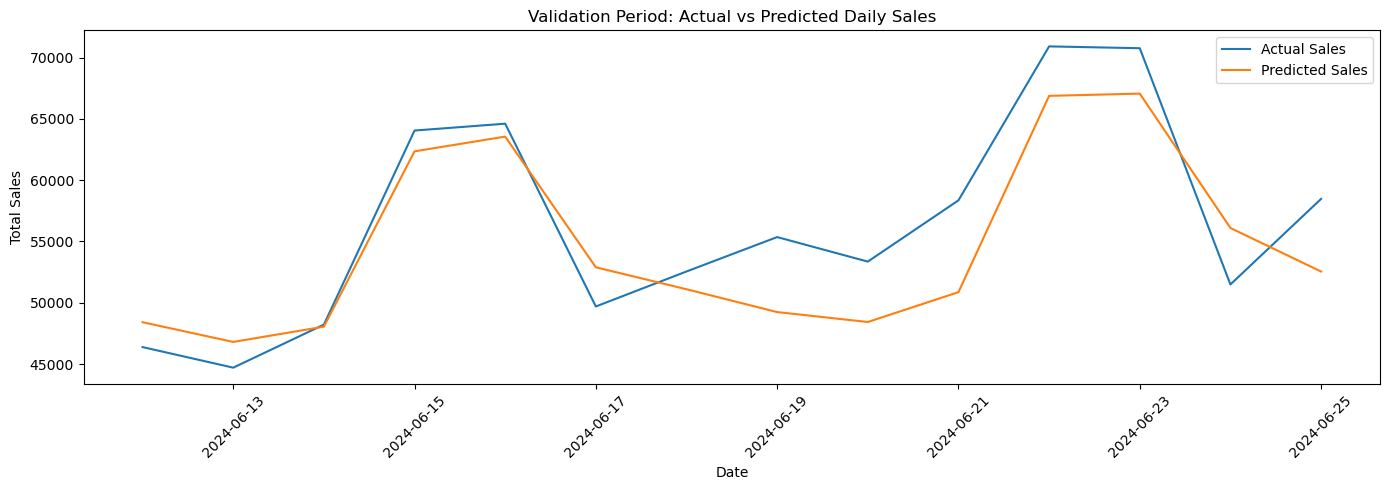

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_error_summary["dt"], daily_error_summary["total_actual_sales"], label="Actual Sales")
plt.plot(daily_error_summary["dt"], daily_error_summary["total_predicted_sales"], label="Predicted Sales")

plt.title("Validation Period: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 13.5 Forecast Error Analysis — Result

Forecast error analysis was conducted to understand where the machine learning model performs well and where it struggles during the validation period.

The overall validation results showed that the model slightly underpredicted total demand. The mean actual sales value was approximately **1.1271**, while the mean predicted sales value was approximately **1.0919**. Total actual sales during validation were approximately **788,935**, while total predicted sales were approximately **764,296**.

The model achieved a mean absolute error of approximately **0.3551** and a median absolute error of approximately **0.2253**. The total absolute error across the validation period was approximately **248,597**.

Daily error analysis showed that the model generally followed the direction of total daily sales, but it slightly underpredicted some high-demand days. In particular, actual sales peaked on **2024-06-22** and **2024-06-23**, while the model predictions were lower than the actual values on both days.

Daily WAPE values ranged from approximately **0.297** to **0.339** across the validation period. The lowest daily WAPE occurred on **2024-06-16**, while the highest daily WAPE occurred on **2024-06-24**.

The actual versus predicted daily sales chart showed that the model captures the overall validation trend reasonably well, but it still struggles with sharp demand spikes and some short-term fluctuations.

Overall, the error analysis indicates that the model provides a useful forecasting improvement over baseline methods, but further improvements may be needed to better capture peak demand periods, promotion-driven effects, and product-store-level volatility.

### 13.6 LightGBM Base Model

LightGBM is tested as the next forecasting model after the initial HistGradientBoostingRegressor model.

The objective is to evaluate whether a LightGBM model can outperform both the best baseline model and the initial machine learning model.

The best baseline model was the 7-day moving average forecast with a WAPE of 0.3399. The HistGradientBoostingRegressor achieved a WAPE of 0.3151. Therefore, the LightGBM model must achieve a WAPE lower than 0.3151 to improve the current forecasting benchmark.

In [31]:
import sys
import subprocess

try:
    import lightgbm as lgb
    print("LightGBM is already installed.")
except ImportError:
    print("LightGBM not found. Installing LightGBM...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "lightgbm"
    ])
    import lightgbm as lgb
    print("LightGBM installed successfully.")

LightGBM not found. Installing LightGBM...
LightGBM installed successfully.


#### Prepare LightGBM Feature Matrices

Categorical-like identifier columns are converted to category data type before training LightGBM.

These fields include product, store, city, category, day-of-week, and month identifiers. Treating these fields as categorical features helps the model avoid interpreting numeric IDs as continuous ordered values.

In [32]:
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()

categorical_features = [
    "city_id",
    "store_id",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "product_id",
    "day_of_week",
    "month"
]

for col in categorical_features:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_valid_lgb[col] = X_valid_lgb[col].astype("category")

print("X_train_lgb shape:", X_train_lgb.shape)
print("X_valid_lgb shape:", X_valid_lgb.shape)

display(X_train_lgb.dtypes)

X_train_lgb shape: (2400000, 33)
X_valid_lgb shape: (700000, 33)


city_id                         category
store_id                        category
management_group_id             category
first_category_id               category
second_category_id              category
third_category_id               category
product_id                      category
day_of_week                     category
is_weekend                         int64
day_of_month                       int64
week_of_year                       int64
month                           category
discount                         float64
holiday_flag                       int64
activity_flag                      int64
precpt                           float64
avg_temperature                  float64
avg_humidity                     float64
avg_wind_level                   float64
sales_lag_1                      float64
sales_lag_7                      float64
sales_lag_14                     float64
sales_lag_28                     float64
rolling_mean_7                   float64
rolling_mean_14 

#### Train Base LightGBM Model

A base LightGBM regression model is trained on the feature-engineered training dataset.

Early stopping is used to stop training when validation performance stops improving. This helps reduce unnecessary training time and lowers the risk of overfitting.

In [33]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
import time
import numpy as np

start_time = time.time()

lgbm_base_model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_base_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric="mae",
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

end_time = time.time()

print("LightGBM base model training completed.")
print("Training time minutes:", round((end_time - start_time) / 60, 2))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.487121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5555
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 33
[LightGBM] [Info] Start training from score 0.700000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l1: 0.389152
[100]	valid_0's l1: 0.3531
[150]	valid_0's l1: 0.348836
[200]	valid_0's l1: 0.347593
[250]	valid_0's l1: 0.346826
[300]	valid_0's l1: 0.346448
[350]	valid_0's l1: 0.346163
[400]	valid_0's l1: 0.346199
Early stopping, best iteration is:
[368]	valid_0's l1: 0.346006
LightGBM base model training completed.
Training time minutes: 3.0


#### Evaluate Base LightGBM Model

The trained LightGBM model is evaluated on the validation period using MAE, RMSE, and WAPE.

Predictions are clipped at zero because sales forecasts should not be negative.

In [34]:
lgbm_valid_pred = lgbm_base_model.predict(X_valid_lgb)

# Sales predictions should not be negative
lgbm_valid_pred = np.clip(lgbm_valid_pred, 0, None)

lgbm_base_metrics = evaluate_forecast(y_valid, lgbm_valid_pred)

lgbm_base_metrics

{'MAE': 0.3459449293438982,
 'RMSE': 0.5904782531054311,
 'WAPE': 0.3069472473636527}

#### Compare LightGBM with Baseline and HistGradientBoosting Models

The LightGBM model is compared against the baseline models and the HistGradientBoostingRegressor model.

The main comparison metric is WAPE because it measures total forecast error relative to total actual demand.

In [35]:
try:
    model_comparison
except NameError:
    model_comparison = pd.read_csv(
        processed_folder / "forecasting_model_comparison.csv"
    )

lgbm_result_row = pd.DataFrame([{
    "model": "lightgbm_base",
    "MAE": lgbm_base_metrics["MAE"],
    "RMSE": lgbm_base_metrics["RMSE"],
    "WAPE": lgbm_base_metrics["WAPE"]
}])

model_comparison_lgbm = pd.concat(
    [model_comparison, lgbm_result_row],
    ignore_index=True
)

model_comparison_lgbm = (
    model_comparison_lgbm
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("WAPE")
)

display(model_comparison_lgbm)

,model,MAE,RMSE,WAPE
5,lightgbm_base,0.345945,0.590478,0.306947
0,hist_gradient_boosting,0.355138,0.619330,0.315104
1,baseline_rolling_mean_7,0.383078,0.631207,0.339895
2,baseline_rolling_mean_28,0.414231,0.701426,0.367536
3,baseline_sales_lag_1,0.464816,0.775418,0.412418
4,baseline_sales_lag_7,0.474657,0.792596,0.421150


#### Save LightGBM Validation Outputs

The LightGBM validation predictions and updated model comparison table are saved locally for later error analysis, reporting, and ensemble modeling.

In [36]:
lgbm_validation_predictions = valid_model_data[[
    "city_id",
    "store_id",
    "product_id",
    "dt",
    "sale_amount"
]].copy()

lgbm_validation_predictions["prediction"] = lgbm_valid_pred
lgbm_validation_predictions["absolute_error"] = (
    lgbm_validation_predictions["sale_amount"] -
    lgbm_validation_predictions["prediction"]
).abs()

lgbm_validation_predictions.to_csv(
    processed_folder / "validation_predictions_lightgbm_base.csv",
    index=False,
    encoding="utf-8-sig"
)

model_comparison_lgbm.to_csv(
    processed_folder / "forecasting_model_comparison_lightgbm.csv",
    index=False,
    encoding="utf-8-sig"
)

print("LightGBM validation predictions and model comparison saved successfully.")

LightGBM validation predictions and model comparison saved successfully.


#### 13.6 LightGBM Base Model — Result

A base LightGBM regression model was trained using the feature-engineered training dataset.

The model was trained on **2,400,000 rows** and evaluated on the **700,000-row validation set**. Categorical-like fields such as product, store, city, category, day-of-week, and month identifiers were converted to category data type before training.

The LightGBM base model achieved:

- **MAE:** 0.3459
- **RMSE:** 0.5905
- **WAPE:** 0.3069

This result outperformed both the best baseline model and the previous HistGradientBoostingRegressor model.

The best baseline model, the 7-day moving average forecast, achieved a WAPE of **0.3399**. The HistGradientBoostingRegressor achieved a WAPE of **0.3151**. LightGBM improved the validation WAPE to **0.3069**, making it the strongest model so far.

The LightGBM validation predictions and updated model comparison table were saved for later tuning, ensemble modeling, and final model selection.

### 13.7 Tuned LightGBM

After the base LightGBM model outperformed all previous models, a small tuning experiment is conducted to test whether different LightGBM hyperparameter settings can further improve validation performance.

The tuning approach is intentionally limited to a few carefully selected configurations to avoid excessive training time on the large dataset.

The objective is to reduce WAPE below the base LightGBM benchmark of 0.3069.

In [38]:
lgbm_tuning_configs = [
    {
        "model_name": "lightgbm_tuned_conservative",
        "params": {
            "objective": "regression_l1",
            "n_estimators": 1200,
            "learning_rate": 0.04,
            "num_leaves": 31,
            "max_depth": 8,
            "min_child_samples": 150,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.1,
            "reg_lambda": 0.5,
            "random_state": 42,
            "n_jobs": -1
        }
    },
    {
        "model_name": "lightgbm_tuned_balanced",
        "params": {
            "objective": "regression_l1",
            "n_estimators": 1500,
            "learning_rate": 0.035,
            "num_leaves": 63,
            "max_depth": 10,
            "min_child_samples": 100,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.05,
            "reg_lambda": 0.3,
            "random_state": 42,
            "n_jobs": -1
        }
    },
    {
        "model_name": "lightgbm_tuned_deeper",
        "params": {
            "objective": "regression_l1",
            "n_estimators": 1800,
            "learning_rate": 0.03,
            "num_leaves": 127,
            "max_depth": 12,
            "min_child_samples": 80,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.05,
            "reg_lambda": 0.2,
            "random_state": 42,
            "n_jobs": -1
        }
    }
]

In [39]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
import time
import numpy as np
import pandas as pd

tuned_lgbm_results = []
tuned_lgbm_predictions = {}

for config in lgbm_tuning_configs:
    model_name = config["model_name"]
    params = config["params"]
    
    print("=" * 80)
    print("Training:", model_name)
    
    start_time = time.time()
    
    model = LGBMRegressor(**params)
    
    model.fit(
        X_train_lgb,
        y_train,
        eval_set=[(X_valid_lgb, y_valid)],
        eval_metric="mae",
        categorical_feature=categorical_features,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    
    pred = model.predict(X_valid_lgb)
    pred = np.clip(pred, 0, None)
    
    metrics = evaluate_forecast(y_valid, pred)
    
    end_time = time.time()
    training_minutes = round((end_time - start_time) / 60, 2)
    
    tuned_lgbm_results.append({
        "model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "WAPE": metrics["WAPE"],
        "training_minutes": training_minutes,
        "best_iteration": model.best_iteration_
    })
    
    tuned_lgbm_predictions[model_name] = pred
    
    print("Completed:", model_name)
    print("Training minutes:", training_minutes)
    print(metrics)

tuned_lgbm_results_df = pd.DataFrame(tuned_lgbm_results).sort_values("WAPE")

display(tuned_lgbm_results_df)

Training: lightgbm_tuned_conservative
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.623012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5555
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 33
[LightGBM] [Info] Start training from score 0.700000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.365582
[200]	valid_0's l1: 0.350799
[300]	valid_0's l1: 0.3489
[400]	valid_0's l1: 0.347693
[500]	valid_0's l1: 0.347269
Early stopping, best iteration is:
[517]	valid_0's l1: 0.347118
Completed: lightgbm_tuned_conservative
Training minutes: 3.71
{'MAE': 0.3470319361479792, 'RMSE': 0.5942967542167521, '

,model,MAE,RMSE,WAPE,training_minutes,best_iteration
1,lightgbm_tuned_balanced,0.345857,0.593280,0.306869,3.33,408
2,lightgbm_tuned_deeper,0.346000,0.596239,0.306996,3.75,327
0,lightgbm_tuned_conservative,0.347032,0.594297,0.307912,3.71,517


In [40]:
model_comparison_all = pd.concat(
    [
        model_comparison_lgbm,
        tuned_lgbm_results_df[["model", "MAE", "RMSE", "WAPE"]]
    ],
    ignore_index=True
)

model_comparison_all = (
    model_comparison_all
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("WAPE")
)

display(model_comparison_all)

,model,MAE,RMSE,WAPE
6,lightgbm_tuned_balanced,0.345857,0.593280,0.306869
0,lightgbm_base,0.345945,0.590478,0.306947
7,lightgbm_tuned_deeper,0.346000,0.596239,0.306996
8,lightgbm_tuned_conservative,0.347032,0.594297,0.307912
1,hist_gradient_boosting,0.355138,0.619330,0.315104
2,baseline_rolling_mean_7,0.383078,0.631207,0.339895
3,baseline_rolling_mean_28,0.414231,0.701426,0.367536
4,baseline_sales_lag_1,0.464816,0.775418,0.412418
5,baseline_sales_lag_7,0.474657,0.792596,0.421150


In [41]:
tuned_lgbm_results_df.to_csv(
    processed_folder / "forecasting_tuned_lightgbm_results.csv",
    index=False,
    encoding="utf-8-sig"
)

model_comparison_all.to_csv(
    processed_folder / "forecasting_model_comparison_all.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tuned LightGBM results and full model comparison saved successfully.")

Tuned LightGBM results and full model comparison saved successfully.


#### 13.7 Tuned LightGBM — Result

A small LightGBM tuning experiment was conducted using three configurations: conservative, balanced, and deeper.

The best-performing tuned model was `lightgbm_tuned_balanced`, which achieved:

- **MAE:** 0.3459
- **RMSE:** 0.5933
- **WAPE:** 0.3069

The tuned balanced model slightly outperformed the base LightGBM model on WAPE. The base LightGBM model achieved a WAPE of **0.306947**, while the tuned balanced model achieved a WAPE of **0.306869**.

Although the improvement was small, the tuned balanced model produced the best WAPE among all tested models so far. However, the base LightGBM model still had a slightly better RMSE, indicating that both models are very close in performance.

The results suggest that LightGBM is currently the strongest forecasting model in the project, outperforming all baseline models and the initial HistGradientBoostingRegressor model.

### 13.8 Simple Ensemble Forecasting

A simple ensemble model is tested by combining predictions from multiple forecasting approaches.

The objective is to determine whether averaging or weighting predictions from different models can improve validation performance.

The ensemble combines:

- HistGradientBoosting predictions
- Base LightGBM predictions
- Tuned LightGBM predictions
- 7-day moving average baseline

The main evaluation metric remains WAPE.

In [42]:
best_tuned_lgbm_name = tuned_lgbm_results_df.iloc[0]["model"]
best_tuned_lgbm_pred = tuned_lgbm_predictions[best_tuned_lgbm_name]

best_tuned_lgbm_predictions_df = valid_model_data[
    ["city_id", "store_id", "product_id", "dt", "sale_amount"]
].copy()

best_tuned_lgbm_predictions_df["prediction"] = best_tuned_lgbm_pred
best_tuned_lgbm_predictions_df["absolute_error"] = (
    best_tuned_lgbm_predictions_df["sale_amount"] -
    best_tuned_lgbm_predictions_df["prediction"]
).abs()

best_tuned_lgbm_predictions_df.to_csv(
    processed_folder / "validation_predictions_lightgbm_tuned_best.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Best tuned LightGBM predictions saved:", best_tuned_lgbm_name)

Best tuned LightGBM predictions saved: lightgbm_tuned_balanced


In [44]:
hgb_preds = pd.read_csv(processed_folder / "validation_predictions_hgb.csv")
lgb_base_preds = pd.read_csv(processed_folder / "validation_predictions_lightgbm_base.csv")
lgb_tuned_preds = pd.read_csv(processed_folder / "validation_predictions_lightgbm_tuned_best.csv")

for df in [hgb_preds, lgb_base_preds, lgb_tuned_preds]:
    df["dt"] = pd.to_datetime(df["dt"])

ensemble_df = valid_model_data[
    ["city_id", "store_id", "product_id", "dt", "sale_amount", "rolling_mean_7"]
].copy()

ensemble_df = ensemble_df.rename(columns={
    "rolling_mean_7": "pred_rolling_mean_7"
})

ensemble_df = ensemble_df.merge(
    hgb_preds[["city_id", "store_id", "product_id", "dt", "prediction"]],
    on=["city_id", "store_id", "product_id", "dt"],
    how="left"
).rename(columns={"prediction": "pred_hgb"})

ensemble_df = ensemble_df.merge(
    lgb_base_preds[["city_id", "store_id", "product_id", "dt", "prediction"]],
    on=["city_id", "store_id", "product_id", "dt"],
    how="left"
).rename(columns={"prediction": "pred_lgb_base"})

ensemble_df = ensemble_df.merge(
    lgb_tuned_preds[["city_id", "store_id", "product_id", "dt", "prediction"]],
    on=["city_id", "store_id", "product_id", "dt"],
    how="left"
).rename(columns={"prediction": "pred_lgb_tuned"})

display(ensemble_df.head())

print("Missing values in ensemble_df:")
display(ensemble_df.isna().sum())


,city_id,store_id,product_id,dt,sale_amount,pred_rolling_mean_7,pred_hgb,pred_lgb_base,pred_lgb_tuned
0,0,0,4,2024-06-12,0.3,1.857143,1.160361,0.925275,0.751546
1,0,0,4,2024-06-13,0.5,1.728571,1.138616,0.863167,0.795880
2,0,0,4,2024-06-14,0.9,1.800000,1.767805,1.190861,0.991318
3,0,0,4,2024-06-15,3.1,1.485714,3.127320,3.045319,3.091033
4,0,0,4,2024-06-16,2.4,1.700000,2.703093,3.473800,3.467308


Missing values in ensemble_df:


city_id                0
store_id               0
product_id             0
dt                     0
sale_amount            0
pred_rolling_mean_7    0
pred_hgb               0
pred_lgb_base          0
pred_lgb_tuned         0
dtype: int64

In [45]:
ensemble_configs = [
    {
        "model": "ensemble_avg_hgb_lgbbase_lgbtuned",
        "weights": {
            "pred_hgb": 1/3,
            "pred_lgb_base": 1/3,
            "pred_lgb_tuned": 1/3
        }
    },
    {
        "model": "ensemble_60_tuned_30_hgb_10_ma7",
        "weights": {
            "pred_lgb_tuned": 0.60,
            "pred_hgb": 0.30,
            "pred_rolling_mean_7": 0.10
        }
    },
    {
        "model": "ensemble_70_tuned_20_hgb_10_ma7",
        "weights": {
            "pred_lgb_tuned": 0.70,
            "pred_hgb": 0.20,
            "pred_rolling_mean_7": 0.10
        }
    },
    {
        "model": "ensemble_60_tuned_30_base_10_ma7",
        "weights": {
            "pred_lgb_tuned": 0.60,
            "pred_lgb_base": 0.30,
            "pred_rolling_mean_7": 0.10
        }
    },
    {
        "model": "ensemble_50_tuned_30_base_20_hgb",
        "weights": {
            "pred_lgb_tuned": 0.50,
            "pred_lgb_base": 0.30,
            "pred_hgb": 0.20
        }
    }
]

ensemble_results = []

for config in ensemble_configs:
    model_name = config["model"]
    weights = config["weights"]
    
    pred = np.zeros(len(ensemble_df))
    
    for pred_col, weight in weights.items():
        pred += ensemble_df[pred_col].values * weight
    
    pred = np.clip(pred, 0, None)
    
    metrics = evaluate_forecast(ensemble_df["sale_amount"], pred)
    
    ensemble_results.append({
        "model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "WAPE": metrics["WAPE"]
    })
    
    ensemble_df[model_name] = pred

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values("WAPE")

display(ensemble_results_df)

,model,MAE,RMSE,WAPE
4,ensemble_50_tuned_30_base_20_hgb,0.344798,0.591801,0.305929
3,ensemble_60_tuned_30_base_10_ma7,0.345103,0.587951,0.306200
0,ensemble_avg_hgb_lgbbase_lgbtuned,0.345144,0.593197,0.306237
2,ensemble_70_tuned_20_hgb_10_ma7,0.345326,0.589943,0.306399
1,ensemble_60_tuned_30_hgb_10_ma7,0.345713,0.591169,0.306741


In [46]:
model_comparison_with_ensemble = pd.concat(
    [
        model_comparison_all,
        ensemble_results_df
    ],
    ignore_index=True
)

model_comparison_with_ensemble = (
    model_comparison_with_ensemble
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("WAPE")
)

display(model_comparison_with_ensemble)

,model,MAE,RMSE,WAPE
9,ensemble_50_tuned_30_base_20_hgb,0.344798,0.591801,0.305929
10,ensemble_60_tuned_30_base_10_ma7,0.345103,0.587951,0.306200
11,ensemble_avg_hgb_lgbbase_lgbtuned,0.345144,0.593197,0.306237
12,ensemble_70_tuned_20_hgb_10_ma7,0.345326,0.589943,0.306399
13,ensemble_60_tuned_30_hgb_10_ma7,0.345713,0.591169,0.306741
0,lightgbm_tuned_balanced,0.345857,0.593280,0.306869
1,lightgbm_base,0.345945,0.590478,0.306947
2,lightgbm_tuned_deeper,0.346000,0.596239,0.306996
3,lightgbm_tuned_conservative,0.347032,0.594297,0.307912
4,hist_gradient_boosting,0.355138,0.619330,0.315104


In [47]:
ensemble_results_df.to_csv(
    processed_folder / "forecasting_ensemble_results.csv",
    index=False,
    encoding="utf-8-sig"
)

model_comparison_with_ensemble.to_csv(
    processed_folder / "forecasting_model_comparison_with_ensemble.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_df.to_csv(
    processed_folder / "validation_predictions_ensemble_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Ensemble results and comparison table saved successfully.")

Ensemble results and comparison table saved successfully.


#### 13.8 Simple Ensemble Forecasting — Result

A simple ensemble experiment was conducted by combining predictions from HistGradientBoosting, Base LightGBM, Tuned LightGBM, and the 7-day moving average baseline.

The best-performing ensemble was:

`ensemble_50_tuned_30_base_20_hgb`

This ensemble used the following weighted combination:

- 50% Tuned LightGBM prediction
- 30% Base LightGBM prediction
- 20% HistGradientBoosting prediction

The best ensemble achieved:

- **MAE:** 0.3448
- **RMSE:** 0.5918
- **WAPE:** 0.3059

This was the best validation result across all tested models.

The ensemble slightly improved over the best single model, `lightgbm_tuned_balanced`, which achieved a WAPE of **0.3069**. It also outperformed the base LightGBM model, the HistGradientBoostingRegressor model, and all baseline forecasting methods.

The results suggest that combining multiple machine learning models can provide a small but useful improvement over individual model predictions. The best ensemble is therefore considered the current leading forecasting model.

### 13.9 Ensemble Error Analysis

After selecting the best-performing ensemble model, forecast errors are analyzed across multiple business dimensions.

The objective is to understand where the ensemble model performs well and where it struggles.

This analysis helps determine whether additional segmented models are needed. If forecast errors are concentrated in specific product classes, stockout conditions, stores, categories, or business periods, segmented modeling may provide additional value.

In [48]:
import pandas as pd
import numpy as np
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

ensemble_df = pd.read_csv(
    processed_folder / "validation_predictions_ensemble_candidates.csv"
)

ensemble_df["dt"] = pd.to_datetime(ensemble_df["dt"])

best_ensemble_model = "ensemble_50_tuned_30_base_20_hgb"

ensemble_error_df = ensemble_df[
    [
        "city_id",
        "store_id",
        "product_id",
        "dt",
        "sale_amount",
        best_ensemble_model
    ]
].copy()

ensemble_error_df = ensemble_error_df.rename(
    columns={best_ensemble_model: "prediction"}
)

ensemble_error_df["prediction"] = np.clip(
    ensemble_error_df["prediction"],
    0,
    None
)

ensemble_error_df["absolute_error"] = (
    ensemble_error_df["sale_amount"] - ensemble_error_df["prediction"]
).abs()

ensemble_error_df["forecast_error"] = (
    ensemble_error_df["sale_amount"] - ensemble_error_df["prediction"]
)

display(ensemble_error_df.head())

,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error,forecast_error
0,0,0,4,2024-06-12,0.3,0.885428,0.585428,-0.585428
1,0,0,4,2024-06-13,0.5,0.884613,0.384613,-0.384613
2,0,0,4,2024-06-14,0.9,1.206478,0.306478,-0.306478
3,0,0,4,2024-06-15,3.1,3.084576,0.015424,0.015424
4,0,0,4,2024-06-16,2.4,3.316413,0.916413,-0.916413


#### Overall Ensemble Error Summary

This summary compares total actual sales, total predicted sales, and total absolute error for the best ensemble model.

It helps identify whether the model is generally overpredicting or underpredicting during the validation period.

In [49]:
ensemble_overall_error_summary = pd.DataFrame({
    "metric": [
        "mean_actual",
        "mean_prediction",
        "mean_absolute_error",
        "median_absolute_error",
        "max_absolute_error",
        "total_actual_sales",
        "total_predicted_sales",
        "total_absolute_error",
        "overall_wape",
        "prediction_bias"
    ],
    "value": [
        ensemble_error_df["sale_amount"].mean(),
        ensemble_error_df["prediction"].mean(),
        ensemble_error_df["absolute_error"].mean(),
        ensemble_error_df["absolute_error"].median(),
        ensemble_error_df["absolute_error"].max(),
        ensemble_error_df["sale_amount"].sum(),
        ensemble_error_df["prediction"].sum(),
        ensemble_error_df["absolute_error"].sum(),
        ensemble_error_df["absolute_error"].sum() / ensemble_error_df["sale_amount"].sum(),
        ensemble_error_df["prediction"].sum() - ensemble_error_df["sale_amount"].sum()
    ]
})

display(ensemble_overall_error_summary)

,metric,value
0,mean_actual,1.127050
1,mean_prediction,1.088977
2,mean_absolute_error,0.344798
3,median_absolute_error,0.217614
4,max_absolute_error,21.047140
5,total_actual_sales,788935.078000
6,total_predicted_sales,762283.960521
7,total_absolute_error,241358.460780
8,overall_wape,0.305929
9,prediction_bias,-26651.117479


#### Daily Ensemble Error Analysis

This analysis evaluates ensemble forecast error by validation date.

It helps identify whether the model performs consistently over time or struggles on specific high-demand or low-demand days.


In [51]:
ensemble_daily_error = (
    ensemble_error_df
    .groupby("dt")
    .agg(
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_daily_error["daily_wape"] = (
    ensemble_daily_error["total_absolute_error"] /
    ensemble_daily_error["total_actual_sales"]
)

ensemble_daily_error["daily_bias"] = (
    ensemble_daily_error["total_predicted_sales"] -
    ensemble_daily_error["total_actual_sales"]
)

display(ensemble_daily_error)

,dt,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,daily_wape,daily_bias
0,2024-06-12,46381.281,49287.614481,14586.854224,0.291737,0.314499,2906.333481
1,2024-06-13,44702.514,46539.710288,13700.189113,0.274004,0.306475,1837.196288
2,2024-06-14,48214.904,48440.976146,15040.296726,0.300806,0.311943,226.072146
3,2024-06-15,64052.176,62161.921514,18235.466339,0.364709,0.284697,-1890.254486
4,2024-06-16,64611.264,63399.026053,18411.330146,0.368227,0.284955,-1212.237947
5,2024-06-17,49695.371,52749.249323,15214.782914,0.304296,0.306161,3053.878323
6,2024-06-18,52551.313,50827.781924,15403.533180,0.308071,0.293114,-1723.531076
7,2024-06-19,55358.983,49624.251937,16556.082529,0.331122,0.299068,-5734.731063
8,2024-06-20,53356.762,48263.776725,16879.404121,0.337588,0.316350,-5092.985275
9,2024-06-21,58356.629,51077.544089,18380.830317,0.367617,0.314974,-7279.084911


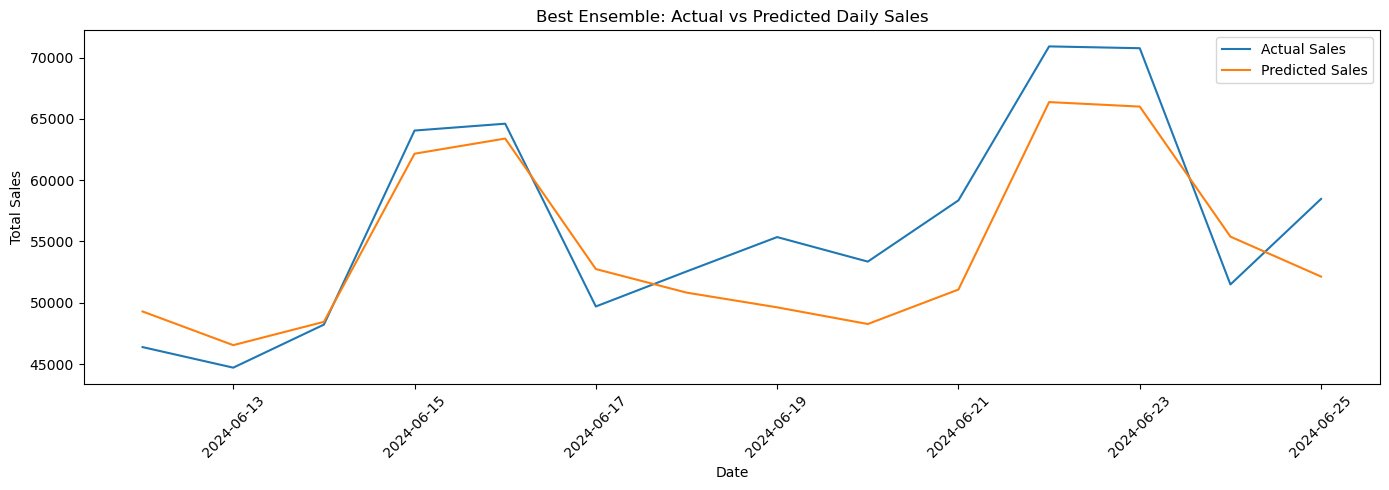

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    ensemble_daily_error["dt"],
    ensemble_daily_error["total_actual_sales"],
    label="Actual Sales"
)

plt.plot(
    ensemble_daily_error["dt"],
    ensemble_daily_error["total_predicted_sales"],
    label="Predicted Sales"
)

plt.title("Best Ensemble: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Product-Level Error Analysis

This analysis identifies products with the highest total forecast error.

The goal is to determine whether forecast errors are concentrated in specific products, especially high-demand or high-stockout products.

In [53]:
ensemble_product_error = (
    ensemble_error_df
    .groupby("product_id")
    .agg(
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_product_error["product_wape"] = (
    ensemble_product_error["total_absolute_error"] /
    ensemble_product_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_product_error["product_bias"] = (
    ensemble_product_error["total_predicted_sales"] -
    ensemble_product_error["total_actual_sales"]
)

top_ensemble_product_errors = (
    ensemble_product_error
    .sort_values("total_absolute_error", ascending=False)
    .head(20)
)

display(top_ensemble_product_errors)

,product_id,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,product_wape,product_bias
300,300,30164.915,28141.347143,10569.423546,1.832424,0.350388,-2023.567857
215,215,33342.939,34666.403695,7035.407622,0.818451,0.211001,1323.464695
70,70,18974.900,20854.919585,6515.664523,1.254460,0.343383,1880.019585
834,834,23335.100,22586.836010,6045.229993,0.582729,0.259062,-748.263990
117,117,20535.520,18774.884960,6002.898021,0.934158,0.292318,-1760.635040
267,267,46032.200,42362.879558,5803.494421,3.164392,0.126075,-3669.320442
4,4,13250.300,15504.836900,5392.373464,0.491915,0.406962,2254.536900
191,191,11178.750,11067.592688,4513.504934,0.903062,0.403758,-111.157312
122,122,17144.170,14412.708779,4191.939665,0.567091,0.244511,-2731.461221
580,580,24562.200,24599.496435,4089.042814,0.397380,0.166477,37.296435


#### Store-Level Error Analysis

This analysis identifies stores with the highest total forecast error.

The goal is to understand whether forecast errors are concentrated in specific store locations.

In [54]:
ensemble_store_error = (
    ensemble_error_df
    .groupby("store_id")
    .agg(
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_store_error["store_wape"] = (
    ensemble_store_error["total_absolute_error"] /
    ensemble_store_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_store_error["store_bias"] = (
    ensemble_store_error["total_predicted_sales"] -
    ensemble_store_error["total_actual_sales"]
)

top_ensemble_store_errors = (
    ensemble_store_error
    .sort_values("total_absolute_error", ascending=False)
    .head(20)
)

display(top_ensemble_store_errors)

,store_id,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,store_wape,store_bias
417,417,2413.83,1614.798995,1019.890102,0.791840,0.422519,-799.031005
263,263,3028.63,2957.573745,855.505253,0.379550,0.282473,-71.056255
18,18,2955.21,2814.911831,833.816463,0.363160,0.282151,-140.298169
343,343,2804.87,2690.853207,811.575605,0.381380,0.289345,-114.016793
182,182,2777.55,2726.574901,796.148898,0.355424,0.286637,-50.975099
145,145,2611.74,2520.606677,781.175193,0.377015,0.299101,-91.133323
235,235,2896.10,2816.468478,777.321662,0.342734,0.268403,-79.631522
556,556,2620.61,2504.507450,767.738784,0.388925,0.292962,-116.102550
555,555,2571.82,2439.622087,765.411043,0.371920,0.297615,-132.197913
822,822,2422.51,2270.185254,757.652839,0.432944,0.312755,-152.324746


#### Add Business and Stockout Context to Error Data

The ensemble predictions are enriched with validation-period business and operational variables.

This allows forecast errors to be analyzed by stockout behavior, holidays, activity periods, discount buckets, categories, cities, and calendar features.

In [55]:
context_cols = [
    "city_id",
    "store_id",
    "product_id",
    "dt",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "stock_hour6_22_cnt",
    "discount",
    "discount_bucket",
    "holiday_flag",
    "activity_flag",
    "is_weekend",
    "day_of_week"
]

ensemble_error_context = ensemble_error_df.merge(
    valid_model_data[context_cols],
    on=["city_id", "store_id", "product_id", "dt"],
    how="left"
)

print("Shape:", ensemble_error_context.shape)
print("Missing values:")
display(ensemble_error_context.isna().sum())

display(ensemble_error_context.head())

Shape: (700000, 19)
Missing values:


city_id                0
store_id               0
product_id             0
dt                     0
sale_amount            0
prediction             0
absolute_error         0
forecast_error         0
management_group_id    0
first_category_id      0
second_category_id     0
third_category_id      0
stock_hour6_22_cnt     0
discount               0
discount_bucket        0
holiday_flag           0
activity_flag          0
is_weekend             0
day_of_week            0
dtype: int64

,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error,forecast_error,management_group_id,first_category_id,second_category_id,third_category_id,stock_hour6_22_cnt,discount,discount_bucket,holiday_flag,activity_flag,is_weekend,day_of_week
0,0,0,4,2024-06-12,0.3,0.885428,0.585428,-0.585428,2,29,78,82,0,0.802,medium_discount,0,1,0,2
1,0,0,4,2024-06-13,0.5,0.884613,0.384613,-0.384613,2,29,78,82,0,0.881,medium_discount,0,1,0,3
2,0,0,4,2024-06-14,0.9,1.206478,0.306478,-0.306478,2,29,78,82,0,0.802,medium_discount,0,1,0,4
3,0,0,4,2024-06-15,3.1,3.084576,0.015424,0.015424,2,29,78,82,7,0.755,medium_discount,1,1,1,5
4,0,0,4,2024-06-16,2.4,3.316413,0.916413,-0.916413,2,29,78,82,0,0.902,low_discount,1,0,1,6


#### Error by Stockout Severity

This analysis evaluates whether forecast errors are higher when products experience more severe stockout exposure.

This is important because stockouts can suppress observed sales and create noisy demand signals.

In [56]:
def classify_stockout_severity(hours):
    if hours == 0:
        return "No Stockout"
    elif hours <= 4:
        return "Low Stockout"
    elif hours <= 8:
        return "Medium Stockout"
    elif hours <= 15:
        return "High Stockout"
    else:
        return "Full-Day Stockout"

ensemble_error_context["stockout_severity"] = (
    ensemble_error_context["stock_hour6_22_cnt"]
    .apply(classify_stockout_severity)
)

ensemble_stockout_error = (
    ensemble_error_context
    .groupby("stockout_severity")
    .agg(
        observations=("sale_amount", "count"),
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_stockout_error["wape"] = (
    ensemble_stockout_error["total_absolute_error"] /
    ensemble_stockout_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_stockout_error["bias"] = (
    ensemble_stockout_error["total_predicted_sales"] -
    ensemble_stockout_error["total_actual_sales"]
)

severity_order = [
    "No Stockout",
    "Low Stockout",
    "Medium Stockout",
    "High Stockout",
    "Full-Day Stockout"
]

ensemble_stockout_error["stockout_severity"] = pd.Categorical(
    ensemble_stockout_error["stockout_severity"],
    categories=severity_order,
    ordered=True
)

ensemble_stockout_error = ensemble_stockout_error.sort_values("stockout_severity")

display(ensemble_stockout_error)

,stockout_severity,observations,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,wape,bias
4,No Stockout,395394,437485.607,417488.008391,127062.008041,0.321355,0.290437,-19997.598609
2,Low Stockout,97300,155868.241,132769.550793,37477.085094,0.385170,0.240441,-23098.690207
3,Medium Stockout,111058,135619.490,124933.938561,34999.952946,0.315150,0.258075,-10685.551439
1,High Stockout,74444,59254.690,70480.557245,25821.455366,0.346857,0.435771,11225.867245
0,Full-Day Stockout,21804,707.050,16611.905531,15997.959334,0.733717,22.626348,15904.855531


#### Error by Holiday and Activity Status

This analysis evaluates whether forecast errors are different during holidays, activity periods, or the overlap between them.

The goal is to determine whether business event periods require additional modeling attention.

In [57]:
ensemble_error_context["holiday_status"] = ensemble_error_context["holiday_flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

ensemble_error_context["activity_status"] = ensemble_error_context["activity_flag"].map({
    0: "No Activity",
    1: "Activity"
})

ensemble_error_context["holiday_activity_segment"] = (
    ensemble_error_context["holiday_status"] + " / " +
    ensemble_error_context["activity_status"]
)

ensemble_holiday_activity_error = (
    ensemble_error_context
    .groupby("holiday_activity_segment")
    .agg(
        observations=("sale_amount", "count"),
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_holiday_activity_error["wape"] = (
    ensemble_holiday_activity_error["total_absolute_error"] /
    ensemble_holiday_activity_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_holiday_activity_error["bias"] = (
    ensemble_holiday_activity_error["total_predicted_sales"] -
    ensemble_holiday_activity_error["total_actual_sales"]
)

display(ensemble_holiday_activity_error)

,holiday_activity_segment,observations,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,wape,bias
0,Holiday / Activity,85979,118321.829,114946.101183,34964.668011,0.406665,0.295505,-3375.727817
1,Holiday / No Activity,114021,152030.918,142996.644096,44685.304172,0.391904,0.293922,-9034.273904
2,Non-Holiday / Activity,202050,217145.426,213429.668077,68465.762540,0.338856,0.315299,-3715.757923
3,Non-Holiday / No Activity,297950,301436.905,290911.547165,93242.726057,0.312948,0.309328,-10525.357835


#### Error by ABC Product Class

This analysis evaluates forecast error across product ABC classes.

ABC classes are based on product sales contribution. This helps determine whether the model performs differently for high-impact products compared with lower-contribution products.

In [58]:
product_abc = pd.read_csv(
    processed_folder / "eda_product_sales_contribution_abc.csv"
)

product_abc = product_abc[["product_id", "abc_class"]].drop_duplicates()

ensemble_error_context = ensemble_error_context.merge(
    product_abc,
    on="product_id",
    how="left"
)

ensemble_abc_error = (
    ensemble_error_context
    .groupby("abc_class")
    .agg(
        observations=("sale_amount", "count"),
        product_count=("product_id", "nunique"),
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_abc_error["wape"] = (
    ensemble_abc_error["total_absolute_error"] /
    ensemble_abc_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_abc_error["bias"] = (
    ensemble_abc_error["total_predicted_sales"] -
    ensemble_abc_error["total_actual_sales"]
)

display(ensemble_abc_error)

,abc_class,observations,product_count,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,wape,bias
0,A,465038,121,639469.168,619537.821076,185848.220186,0.399641,0.290629,-19931.346924
1,B,171948,167,111622.044,106317.140797,41169.171748,0.239428,0.368827,-5304.903203
2,C,63014,577,37843.866,36428.998649,14341.068846,0.227585,0.378954,-1414.867351


#### Error by Category Level

This analysis evaluates forecast errors at the category level.

The objective is to identify whether specific product hierarchy groups have higher forecast errors.

In [59]:
ensemble_first_category_error = (
    ensemble_error_context
    .groupby("first_category_id")
    .agg(
        observations=("sale_amount", "count"),
        product_count=("product_id", "nunique"),
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

ensemble_first_category_error["wape"] = (
    ensemble_first_category_error["total_absolute_error"] /
    ensemble_first_category_error["total_actual_sales"].replace(0, np.nan)
)

ensemble_first_category_error["bias"] = (
    ensemble_first_category_error["total_predicted_sales"] -
    ensemble_first_category_error["total_actual_sales"]
)

top_first_category_errors = (
    ensemble_first_category_error
    .sort_values("total_absolute_error", ascending=False)
    .head(20)
)

display(top_first_category_errors)

,first_category_id,observations,product_count,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,wape,bias
4,4,152432,95,198417.538,196007.993308,64022.011893,0.420004,0.322663,-2409.544692
20,20,77462,75,126761.716,120200.200710,39532.169405,0.510343,0.311862,-6561.515290
16,16,100478,90,73181.540,70143.670241,20279.704387,0.201832,0.277115,-3037.869759
29,29,48944,10,70816.500,68655.951482,19957.474807,0.407761,0.281820,-2160.548518
21,21,39802,62,96495.418,91208.861242,18436.549228,0.463207,0.191061,-5286.556758
28,28,27972,34,40350.360,38489.302164,12339.519531,0.441138,0.305809,-1861.057836
10,10,39732,48,27069.730,25152.104912,11453.203930,0.288261,0.423100,-1917.625088
5,5,23100,64,21943.574,20548.070400,10014.602745,0.433533,0.456380,-1395.503600
8,8,40390,44,26700.180,25748.314803,9586.322624,0.237344,0.359036,-951.865197
18,18,32886,48,24549.900,23638.294183,7620.384719,0.231721,0.310404,-911.605817


#### Save Ensemble Error Analysis Outputs

The ensemble error analysis outputs are saved locally for reporting and to support the decision on whether segmented models are needed.

In [60]:
ensemble_overall_error_summary.to_csv(
    processed_folder / "ensemble_overall_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_daily_error.to_csv(
    processed_folder / "ensemble_daily_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_product_error.to_csv(
    processed_folder / "ensemble_product_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_store_error.to_csv(
    processed_folder / "ensemble_store_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_stockout_error.to_csv(
    processed_folder / "ensemble_stockout_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_holiday_activity_error.to_csv(
    processed_folder / "ensemble_holiday_activity_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_abc_error.to_csv(
    processed_folder / "ensemble_abc_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_first_category_error.to_csv(
    processed_folder / "ensemble_first_category_error_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_error_context.to_csv(
    processed_folder / "ensemble_error_context_full.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Ensemble error analysis outputs saved successfully.")

Ensemble error analysis outputs saved successfully.


#### 13.9 Ensemble Error Analysis — Result

The best-performing ensemble model was analyzed across multiple business dimensions to understand where it performs well and where it struggles.

The ensemble achieved an overall WAPE of **0.3059**, with a mean absolute error of **0.3448**. Total actual validation sales were approximately **788,935**, while total predicted sales were approximately **762,284**, indicating a total prediction bias of approximately **-26,651**. This shows that the model slightly underpredicted total validation demand.

Daily error analysis showed that the model followed the general direction of demand across the validation period. However, it slightly underpredicted some high-demand days, especially around **2024-06-22** and **2024-06-23**. Daily WAPE values ranged from approximately **0.285** to **0.332**, showing relatively stable performance across the validation window.

Product-level error analysis showed that forecast errors were concentrated in several high-volume products, including products `300`, `215`, `70`, `834`, `117`, `267`, and `4`. Some high-volume products had large absolute errors but relatively moderate WAPE, while some lower-volume products had much higher WAPE values.

Store-level error analysis showed that some stores had larger forecast errors, with store `417` showing particularly high underprediction. Several high-sales stores also appeared among the top-error stores, suggesting that demand centers remain challenging to forecast accurately.

The most important finding came from stockout severity analysis. The model performed well for no-stockout, low-stockout, and medium-stockout observations, but struggled significantly with high and full-day stockout cases. Full-day stockout observations had extremely high WAPE because actual sales were very low while model predictions remained much higher. This indicates that the model tends to overpredict when products are unavailable for the full monitored window.

Holiday and activity error analysis showed that the model performed reasonably well during holiday periods. Holiday segments had lower WAPE than non-holiday segments, suggesting that holiday and activity features helped capture these calendar effects.

ABC error analysis showed that the model performed best on A-class products, with a WAPE of approximately **0.291**. B and C products had higher WAPE values of approximately **0.369** and **0.379**, respectively. This indicates that lower-volume products are more difficult to forecast accurately when measured by relative error.

Overall, the error analysis suggests that the current ensemble model is strong, but the main remaining weakness is related to severe stockout conditions, especially full-day stockout cases. This supports the need for stockout-aware model refinement or segmented modeling focused on high-stockout observations.

### 13.10 Stockout-Aware Forecast Correction

The ensemble error analysis showed that the best ensemble model performs well overall, but struggles with severe stockout cases, especially full-day stockout observations.

In full-day stockout cases, actual sales are often close to zero because the product is unavailable for the full monitored window. However, the model may still predict positive sales based on historical demand patterns.

This step tests stockout-aware correction rules that reduce predictions for high-stockout and full-day-stockout observations.

The objective is to determine whether a simple post-processing correction can improve validation WAPE and reduce overprediction in severe stockout conditions.

In [61]:
import pandas as pd
import numpy as np
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

ensemble_error_context = pd.read_csv(
    processed_folder / "ensemble_error_context_full.csv"
)

ensemble_error_context["dt"] = pd.to_datetime(ensemble_error_context["dt"])

print("Shape:", ensemble_error_context.shape)
display(ensemble_error_context.head())

Shape: (700000, 24)


,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error,forecast_error,management_group_id,first_category_id,...,discount_bucket,holiday_flag,activity_flag,is_weekend,day_of_week,stockout_severity,holiday_status,activity_status,holiday_activity_segment,abc_class
0,0,0,4,2024-06-12,0.3,0.885428,0.585428,-0.585428,2,29,...,medium_discount,0,1,0,2,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A
1,0,0,4,2024-06-13,0.5,0.884613,0.384613,-0.384613,2,29,...,medium_discount,0,1,0,3,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A
2,0,0,4,2024-06-14,0.9,1.206478,0.306478,-0.306478,2,29,...,medium_discount,0,1,0,4,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A
3,0,0,4,2024-06-15,3.1,3.084576,0.015424,0.015424,2,29,...,medium_discount,1,1,1,5,Medium Stockout,Holiday,Activity,Holiday / Activity,A
4,0,0,4,2024-06-16,2.4,3.316413,0.916413,-0.916413,2,29,...,low_discount,1,0,1,6,No Stockout,Holiday,No Activity,Holiday / No Activity,A


#### Recreate Stockout Severity Buckets

Stockout severity buckets are recreated using `stock_hour6_22_cnt`.

These buckets will be used to apply different correction factors to model predictions.

In [62]:
def classify_stockout_severity(hours):
    if hours == 0:
        return "No Stockout"
    elif hours <= 4:
        return "Low Stockout"
    elif hours <= 8:
        return "Medium Stockout"
    elif hours <= 15:
        return "High Stockout"
    else:
        return "Full-Day Stockout"

ensemble_error_context["stockout_severity"] = (
    ensemble_error_context["stock_hour6_22_cnt"]
    .apply(classify_stockout_severity)
)

display(
    ensemble_error_context["stockout_severity"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "stockout_severity", "stockout_severity": "count"})
)

,count,count
0,No Stockout,395394
1,Medium Stockout,111058
2,Low Stockout,97300
3,High Stockout,74444
4,Full-Day Stockout,21804


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape
    }

#### Test Stockout Correction Factors

Different correction factors are tested for high-stockout and full-day-stockout observations.

No-stockout, low-stockout, and medium-stockout predictions are kept unchanged. Only severe stockout cases are adjusted.

The goal is to reduce overprediction in severe stockout conditions without harming overall validation performance.

In [65]:
base_prediction_col = "prediction"

high_stockout_factors = [1.00, 0.95, 0.90, 0.85, 0.80, 0.75]
full_day_stockout_factors = [1.00, 0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.00]

correction_results = []

for high_factor in high_stockout_factors:
    for full_factor in full_day_stockout_factors:
        
        corrected_pred = ensemble_error_context[base_prediction_col].copy()
        
        corrected_pred = np.where(
            ensemble_error_context["stockout_severity"] == "High Stockout",
            corrected_pred * high_factor,
            corrected_pred
        )
        
        corrected_pred = np.where(
            ensemble_error_context["stockout_severity"] == "Full-Day Stockout",
            corrected_pred * full_factor,
            corrected_pred
        )
        
        corrected_pred = np.clip(corrected_pred, 0, None)
        
        metrics = evaluate_forecast(
            ensemble_error_context["sale_amount"],
            corrected_pred
        )
        
        correction_results.append({
            "model": f"stockout_corrected_high_{high_factor}_full_{full_factor}",
            "high_stockout_factor": high_factor,
            "full_day_stockout_factor": full_factor,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "WAPE": metrics["WAPE"]
        })

correction_results_df = pd.DataFrame(correction_results).sort_values("WAPE")

display(correction_results_df.head(20))

,model,high_stockout_factor,full_day_stockout_factor,MAE,RMSE,WAPE
39,stockout_corrected_high_0.8_full_0.0,0.80,0.00,0.320040,0.547573,0.283963
31,stockout_corrected_high_0.85_full_0.0,0.85,0.00,0.320054,0.548918,0.283975
38,stockout_corrected_high_0.8_full_0.02,0.80,0.02,0.320280,0.547538,0.284176
30,stockout_corrected_high_0.85_full_0.02,0.85,0.02,0.320294,0.548883,0.284188
47,stockout_corrected_high_0.75_full_0.0,0.75,0.00,0.320508,0.547125,0.284378
23,stockout_corrected_high_0.9_full_0.0,0.90,0.00,0.320549,0.551152,0.284414
37,stockout_corrected_high_0.8_full_0.05,0.80,0.05,0.320699,0.547542,0.284548
29,stockout_corrected_high_0.85_full_0.05,0.85,0.05,0.320713,0.548887,0.284560
46,stockout_corrected_high_0.75_full_0.02,0.75,0.02,0.320748,0.547090,0.284591
22,stockout_corrected_high_0.9_full_0.02,0.90,0.02,0.320789,0.551117,0.284627


#### Compare Stockout-Corrected Forecasts Against Original Ensemble

The best stockout-corrected forecast is compared against the original best ensemble model.

This comparison determines whether stockout-aware post-processing improves validation performance.

In [66]:
original_ensemble_metrics = evaluate_forecast(
    ensemble_error_context["sale_amount"],
    ensemble_error_context["prediction"]
)

original_ensemble_row = pd.DataFrame([{
    "model": "original_best_ensemble",
    "high_stockout_factor": 1.0,
    "full_day_stockout_factor": 1.0,
    "MAE": original_ensemble_metrics["MAE"],
    "RMSE": original_ensemble_metrics["RMSE"],
    "WAPE": original_ensemble_metrics["WAPE"]
}])

correction_comparison_df = pd.concat(
    [original_ensemble_row, correction_results_df],
    ignore_index=True
).sort_values("WAPE")

display(correction_comparison_df.head(20))

,model,high_stockout_factor,full_day_stockout_factor,MAE,RMSE,WAPE
1,stockout_corrected_high_0.8_full_0.0,0.80,0.00,0.320040,0.547573,0.283963
2,stockout_corrected_high_0.85_full_0.0,0.85,0.00,0.320054,0.548918,0.283975
3,stockout_corrected_high_0.8_full_0.02,0.80,0.02,0.320280,0.547538,0.284176
4,stockout_corrected_high_0.85_full_0.02,0.85,0.02,0.320294,0.548883,0.284188
5,stockout_corrected_high_0.75_full_0.0,0.75,0.00,0.320508,0.547125,0.284378
6,stockout_corrected_high_0.9_full_0.0,0.90,0.00,0.320549,0.551152,0.284414
7,stockout_corrected_high_0.8_full_0.05,0.80,0.05,0.320699,0.547542,0.284548
8,stockout_corrected_high_0.85_full_0.05,0.85,0.05,0.320713,0.548887,0.284560
9,stockout_corrected_high_0.75_full_0.02,0.75,0.02,0.320748,0.547090,0.284591
10,stockout_corrected_high_0.9_full_0.02,0.90,0.02,0.320789,0.551117,0.284627


In [67]:
best_correction = correction_results_df.iloc[0]

best_high_factor = best_correction["high_stockout_factor"]
best_full_factor = best_correction["full_day_stockout_factor"]

print("Best high stockout factor:", best_high_factor)
print("Best full-day stockout factor:", best_full_factor)
print("Best corrected WAPE:", best_correction["WAPE"])

ensemble_error_context["stockout_corrected_prediction"] = ensemble_error_context["prediction"].copy()

ensemble_error_context["stockout_corrected_prediction"] = np.where(
    ensemble_error_context["stockout_severity"] == "High Stockout",
    ensemble_error_context["stockout_corrected_prediction"] * best_high_factor,
    ensemble_error_context["stockout_corrected_prediction"]
)

ensemble_error_context["stockout_corrected_prediction"] = np.where(
    ensemble_error_context["stockout_severity"] == "Full-Day Stockout",
    ensemble_error_context["stockout_corrected_prediction"] * best_full_factor,
    ensemble_error_context["stockout_corrected_prediction"]
)

ensemble_error_context["stockout_corrected_prediction"] = np.clip(
    ensemble_error_context["stockout_corrected_prediction"],
    0,
    None
)

ensemble_error_context["stockout_corrected_absolute_error"] = (
    ensemble_error_context["sale_amount"] -
    ensemble_error_context["stockout_corrected_prediction"]
).abs()

display(ensemble_error_context.head())

Best high stockout factor: 0.8
Best full-day stockout factor: 0.0
Best corrected WAPE: 0.2839625771414404


,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error,forecast_error,management_group_id,first_category_id,...,activity_flag,is_weekend,day_of_week,stockout_severity,holiday_status,activity_status,holiday_activity_segment,abc_class,stockout_corrected_prediction,stockout_corrected_absolute_error
0,0,0,4,2024-06-12,0.3,0.885428,0.585428,-0.585428,2,29,...,1,0,2,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,0.885428,0.585428
1,0,0,4,2024-06-13,0.5,0.884613,0.384613,-0.384613,2,29,...,1,0,3,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,0.884613,0.384613
2,0,0,4,2024-06-14,0.9,1.206478,0.306478,-0.306478,2,29,...,1,0,4,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,1.206478,0.306478
3,0,0,4,2024-06-15,3.1,3.084576,0.015424,0.015424,2,29,...,1,1,5,Medium Stockout,Holiday,Activity,Holiday / Activity,A,3.084576,0.015424
4,0,0,4,2024-06-16,2.4,3.316413,0.916413,-0.916413,2,29,...,0,1,6,No Stockout,Holiday,No Activity,Holiday / No Activity,A,3.316413,0.916413


#### Stockout Severity Error After Correction

This analysis compares forecast performance by stockout severity after applying the best correction rule.

The key objective is to verify whether errors in high and full-day stockout cases were reduced.

In [69]:
corrected_stockout_error = (
    ensemble_error_context
    .groupby("stockout_severity")
    .agg(
        observations=("sale_amount", "count"),
        total_actual_sales=("sale_amount", "sum"),
        total_corrected_predicted_sales=("stockout_corrected_prediction", "sum"),
        total_corrected_absolute_error=("stockout_corrected_absolute_error", "sum"),
        avg_corrected_absolute_error=("stockout_corrected_absolute_error", "mean")
    )
    .reset_index()
)

corrected_stockout_error["corrected_wape"] = (
    corrected_stockout_error["total_corrected_absolute_error"] /
    corrected_stockout_error["total_actual_sales"].replace(0, np.nan)
)

corrected_stockout_error["corrected_bias"] = (
    corrected_stockout_error["total_corrected_predicted_sales"] -
    corrected_stockout_error["total_actual_sales"]
)

severity_order = [
    "No Stockout",
    "Low Stockout",
    "Medium Stockout",
    "High Stockout",
    "Full-Day Stockout"
]

corrected_stockout_error["stockout_severity"] = pd.Categorical(
    corrected_stockout_error["stockout_severity"],
    categories=severity_order,
    ordered=True
)

corrected_stockout_error = corrected_stockout_error.sort_values("stockout_severity")

display(corrected_stockout_error)

,stockout_severity,observations,total_actual_sales,total_corrected_predicted_sales,total_corrected_absolute_error,avg_corrected_absolute_error,corrected_wape,corrected_bias
4,No Stockout,395394,437485.607,417488.008391,127062.008041,0.321355,0.290437,-19997.598609
2,Low Stockout,97300,155868.241,132769.550793,37477.085094,0.385170,0.240441,-23098.690207
3,Medium Stockout,111058,135619.490,124933.938561,34999.952946,0.315150,0.258075,-10685.551439
1,High Stockout,74444,59254.690,56384.445796,23781.941866,0.319461,0.401351,-2870.244204
0,Full-Day Stockout,21804,707.050,0.000000,707.050000,0.032428,1.000000,-707.050000


In [70]:
stockout_corrected_metrics = evaluate_forecast(
    ensemble_error_context["sale_amount"],
    ensemble_error_context["stockout_corrected_prediction"]
)

stockout_corrected_metrics

{'MAE': 0.3200400542088048,
 'RMSE': 0.5475734088047813,
 'WAPE': 0.2839625771414404}

#### Save Stockout-Aware Correction Outputs

The stockout-aware correction results and corrected predictions are saved locally for reporting and final model comparison.

In [71]:
correction_results_df.to_csv(
    processed_folder / "stockout_correction_results.csv",
    index=False,
    encoding="utf-8-sig"
)

correction_comparison_df.to_csv(
    processed_folder / "stockout_correction_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

corrected_stockout_error.to_csv(
    processed_folder / "stockout_corrected_error_by_severity.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_error_context.to_csv(
    processed_folder / "ensemble_stockout_corrected_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Stockout-aware correction outputs saved successfully.")

Stockout-aware correction outputs saved successfully.


#### 13.10 Stockout-Aware Forecast Correction — Result

A stockout-aware correction experiment was conducted to reduce overprediction in severe stockout cases.

The best-performing correction rule used the following factors:

- **High Stockout factor:** 0.80
- **Full-Day Stockout factor:** 0.00

This means that predictions for high-stockout observations were reduced by 20%, while predictions for full-day stockout observations were set to zero.

The original best ensemble model achieved:

- **MAE:** 0.3448
- **RMSE:** 0.5918
- **WAPE:** 0.3059

After applying the stockout-aware correction, performance improved to:

- **MAE:** 0.3200
- **RMSE:** 0.5476
- **WAPE:** 0.2840

This represents a meaningful improvement over the original ensemble model. The correction was especially effective because the original model strongly overpredicted full-day stockout observations.

Before correction, full-day stockout observations had very low actual sales but much higher predicted sales. After applying the correction, predictions for full-day stockout cases were reduced to zero, significantly lowering total forecast error.

The results confirm that severe stockout conditions are one of the main drivers of forecast error. A stockout-aware post-processing step can substantially improve validation performance when same-day stockout exposure is known or can be estimated.

However, this correction should be interpreted carefully. In a real future forecasting scenario, actual same-day stockout hours may not be known at prediction time. Therefore, this correction is most appropriate when stockout information is available operationally or when a stockout-risk forecast is used as a proxy.
`

### 13.11 ABC Segment Analysis After Stockout Correction

After applying the stockout-aware correction, forecast performance is analyzed across ABC product classes.

ABC classes were created earlier based on product sales contribution:

- A products: highest sales contribution
- B products: medium sales contribution
- C products: lower sales contribution

The objective is to determine whether the stockout-aware correction improved performance across product importance segments and whether separate segmented models may still be needed for B or C products.

In [72]:
import pandas as pd
import numpy as np
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

corrected_predictions = pd.read_csv(
    processed_folder / "ensemble_stockout_corrected_predictions.csv"
)

corrected_predictions["dt"] = pd.to_datetime(corrected_predictions["dt"])

print("Corrected predictions shape:", corrected_predictions.shape)
display(corrected_predictions.head())

Corrected predictions shape: (700000, 26)


,city_id,store_id,product_id,dt,sale_amount,prediction,absolute_error,forecast_error,management_group_id,first_category_id,...,activity_flag,is_weekend,day_of_week,stockout_severity,holiday_status,activity_status,holiday_activity_segment,abc_class,stockout_corrected_prediction,stockout_corrected_absolute_error
0,0,0,4,2024-06-12,0.3,0.885428,0.585428,-0.585428,2,29,...,1,0,2,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,0.885428,0.585428
1,0,0,4,2024-06-13,0.5,0.884613,0.384613,-0.384613,2,29,...,1,0,3,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,0.884613,0.384613
2,0,0,4,2024-06-14,0.9,1.206478,0.306478,-0.306478,2,29,...,1,0,4,No Stockout,Non-Holiday,Activity,Non-Holiday / Activity,A,1.206478,0.306478
3,0,0,4,2024-06-15,3.1,3.084576,0.015424,0.015424,2,29,...,1,1,5,Medium Stockout,Holiday,Activity,Holiday / Activity,A,3.084576,0.015424
4,0,0,4,2024-06-16,2.4,3.316413,0.916413,-0.916413,2,29,...,0,1,6,No Stockout,Holiday,No Activity,Holiday / No Activity,A,3.316413,0.916413


#### Original vs Corrected Error by ABC Class

This analysis compares the original ensemble forecast performance with the stockout-corrected forecast performance across ABC product classes.

The purpose is to understand whether the correction improved performance for high-impact A products as well as lower-volume B and C products.

In [73]:
abc_correction_comparison = (
    corrected_predictions
    .groupby("abc_class")
    .agg(
        observations=("sale_amount", "count"),
        product_count=("product_id", "nunique"),
        total_actual_sales=("sale_amount", "sum"),
        original_predicted_sales=("prediction", "sum"),
        corrected_predicted_sales=("stockout_corrected_prediction", "sum"),
        original_absolute_error=("absolute_error", "sum"),
        corrected_absolute_error=("stockout_corrected_absolute_error", "sum")
    )
    .reset_index()
)

abc_correction_comparison["original_wape"] = (
    abc_correction_comparison["original_absolute_error"] /
    abc_correction_comparison["total_actual_sales"].replace(0, np.nan)
)

abc_correction_comparison["corrected_wape"] = (
    abc_correction_comparison["corrected_absolute_error"] /
    abc_correction_comparison["total_actual_sales"].replace(0, np.nan)
)

abc_correction_comparison["wape_improvement"] = (
    abc_correction_comparison["original_wape"] -
    abc_correction_comparison["corrected_wape"]
)

abc_correction_comparison["original_bias"] = (
    abc_correction_comparison["original_predicted_sales"] -
    abc_correction_comparison["total_actual_sales"]
)

abc_correction_comparison["corrected_bias"] = (
    abc_correction_comparison["corrected_predicted_sales"] -
    abc_correction_comparison["total_actual_sales"]
)

abc_correction_comparison["bias_change"] = (
    abc_correction_comparison["corrected_bias"] -
    abc_correction_comparison["original_bias"]
)

display(abc_correction_comparison)

,abc_class,observations,product_count,total_actual_sales,original_predicted_sales,corrected_predicted_sales,original_absolute_error,corrected_absolute_error,original_wape,corrected_wape,wape_improvement,original_bias,corrected_bias,bias_change
0,A,465038,121,639469.168,619537.821076,595275.985720,185848.220186,171143.747465,0.290629,0.267634,0.022995,-19931.346924,-44193.182280,-24261.835356
1,B,171948,167,111622.044,106317.140797,101362.197282,41169.171748,39041.601986,0.368827,0.349766,0.019060,-5304.903203,-10259.846718,-4954.943514
2,C,63014,577,37843.866,36428.998649,34937.760539,14341.068846,13842.688495,0.378954,0.365784,0.013169,-1414.867351,-2906.105461,-1491.238110


#### ABC Class Performance Interpretation

The key metrics reviewed in this comparison are:

- `original_wape`: WAPE before stockout correction
- `corrected_wape`: WAPE after stockout correction
- `wape_improvement`: reduction in WAPE after correction
- `original_bias`: prediction bias before correction
- `corrected_bias`: prediction bias after correction

A positive `wape_improvement` means the stockout-aware correction improved performance for that ABC class.
``

In [74]:
abc_correction_comparison["sales_share_percent"] = (
    abc_correction_comparison["total_actual_sales"] /
    abc_correction_comparison["total_actual_sales"].sum() * 100
)

abc_correction_comparison["corrected_error_share_percent"] = (
    abc_correction_comparison["corrected_absolute_error"] /
    abc_correction_comparison["corrected_absolute_error"].sum() * 100
)

display(abc_correction_comparison[
    [
        "abc_class",
        "product_count",
        "observations",
        "total_actual_sales",
        "sales_share_percent",
        "original_wape",
        "corrected_wape",
        "wape_improvement",
        "corrected_error_share_percent",
        "original_bias",
        "corrected_bias"
    ]
])

,abc_class,product_count,observations,total_actual_sales,sales_share_percent,original_wape,corrected_wape,wape_improvement,corrected_error_share_percent,original_bias,corrected_bias
0,A,121,465038,639469.168,81.054726,0.290629,0.267634,0.022995,76.393897,-19931.346924,-44193.182280
1,B,167,171948,111622.044,14.148445,0.368827,0.349766,0.019060,17.427105,-5304.903203,-10259.846718
2,C,577,63014,37843.866,4.796829,0.378954,0.365784,0.013169,6.178998,-1414.867351,-2906.105461


#### Visual Comparison of ABC WAPE Before and After Correction

This chart compares original WAPE and corrected WAPE across ABC classes.

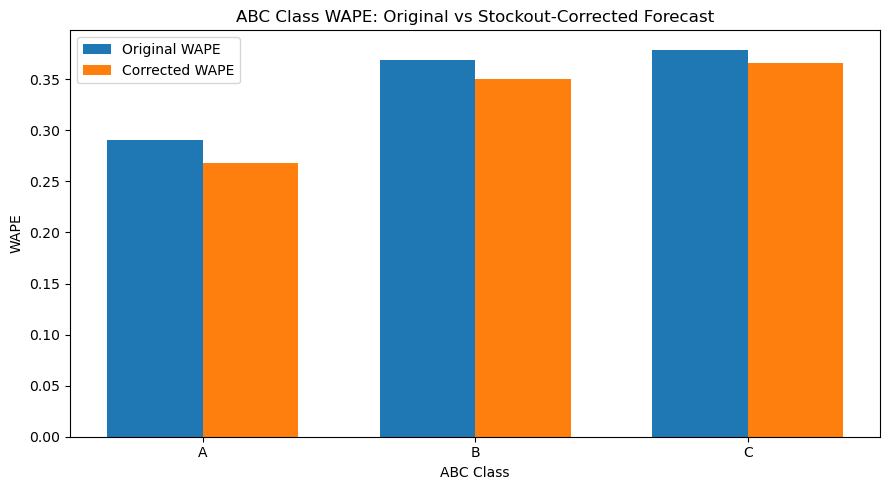

In [75]:
import matplotlib.pyplot as plt
import numpy as np

abc_plot = abc_correction_comparison.sort_values("abc_class")

x = np.arange(len(abc_plot["abc_class"]))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, abc_plot["original_wape"], width, label="Original WAPE")
plt.bar(x + width/2, abc_plot["corrected_wape"], width, label="Corrected WAPE")

plt.title("ABC Class WAPE: Original vs Stockout-Corrected Forecast")
plt.xlabel("ABC Class")
plt.ylabel("WAPE")
plt.xticks(x, abc_plot["abc_class"])
plt.legend()
plt.tight_layout()
plt.show()

#### ABC Segment Decision

This step helps decide whether separate models are needed for A, B, or C product classes.

If the corrected model performs well for A products but remains weak for B and C products, a separate B/C model may be tested later. However, if the corrected model improves all ABC classes sufficiently, the global stockout-corrected ensemble may be retained as the final forecasting approach.

In [76]:
abc_segment_decision = abc_correction_comparison.copy()

def recommend_abc_action(row):
    if row["corrected_wape"] <= 0.30:
        return "Strong performance - keep global corrected model"
    elif row["corrected_wape"] <= 0.40:
        return "Moderate performance - monitor segment"
    else:
        return "Weak performance - consider segmented model"

abc_segment_decision["recommended_action"] = abc_segment_decision.apply(
    recommend_abc_action,
    axis=1
)

display(abc_segment_decision[
    [
        "abc_class",
        "product_count",
        "sales_share_percent",
        "corrected_wape",
        "wape_improvement",
        "corrected_bias",
        "recommended_action"
    ]
])

,abc_class,product_count,sales_share_percent,corrected_wape,wape_improvement,corrected_bias,recommended_action
0,A,121,81.054726,0.267634,0.022995,-44193.182280,Strong performance - keep global corrected model
1,B,167,14.148445,0.349766,0.019060,-10259.846718,Moderate performance - monitor segment
2,C,577,4.796829,0.365784,0.013169,-2906.105461,Moderate performance - monitor segment


#### Save ABC Correction Analysis Outputs

The ABC correction analysis outputs are saved locally to support final model selection and reporting.

In [77]:
abc_correction_comparison.to_csv(
    processed_folder / "abc_correction_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

abc_segment_decision.to_csv(
    processed_folder / "abc_segment_decision.csv",
    index=False,
    encoding="utf-8-sig"
)

print("ABC correction analysis outputs saved successfully.")

ABC correction analysis outputs saved successfully.


#### 13.11 ABC Segment Analysis After Stockout Correction — Result

ABC segment analysis was performed after applying the stockout-aware correction to evaluate whether the correction improved forecast performance across product importance classes.

The correction improved WAPE across all ABC classes.

For **A products**, WAPE improved from **0.2906** to **0.2676**. This is the most important result because A products contributed approximately **81.05%** of validation sales. The corrected model performs strongly on the highest-impact product class.

For **B products**, WAPE improved from **0.3688** to **0.3498**. This indicates moderate improvement, although B products remain more difficult to forecast than A products.

For **C products**, WAPE improved from **0.3790** to **0.3658**. C products still have the highest relative error, which is expected because they are lower-volume products with noisier demand behavior. However, C products contributed only approximately **4.80%** of validation sales.

The ABC analysis shows that the stockout-aware correction improved all product classes, with the strongest business impact occurring in A products. Since A products represent the majority of sales and the corrected model performs well on this segment, a separate A-product model is not required at this stage.

B and C products still show higher relative forecasting error, but their lower sales contribution reduces their overall business impact. Therefore, the current recommendation is to retain the global stockout-corrected ensemble model as the leading forecasting approach and monitor B/C products as potential future segmentation candidates.

One important trade-off is that the corrected model increased underprediction bias across all ABC classes. This is expected because the correction reduces predictions in severe stockout cases. The correction improves overall WAPE but should be interpreted as a stockout-aware adjustment rather than a pure unconstrained demand forecast.

### 13.12 Final Model Selection and Saving

After evaluating baseline models, HistGradientBoosting, LightGBM, tuned LightGBM, simple ensemble models, and stockout-aware correction, the final forecasting approach was selected.

The best-performing approach was the **Stockout-Corrected Ensemble Forecast**.

This approach combines:

- 50% Tuned LightGBM prediction
- 30% Base LightGBM prediction
- 20% HistGradientBoosting prediction

After generating the ensemble forecast, a stockout-aware correction is applied:

- High Stockout predictions are multiplied by 0.80
- Full-Day Stockout predictions are multiplied by 0.00

This approach achieved the best validation performance:

- MAE: 0.3200
- RMSE: 0.5476
- WAPE: 0.2840

The model components, feature metadata, ensemble weights, and correction rules are saved so they can be reused in later forecasting, evaluation, and Power BI output generation steps without retraining all models from scratch.

In [78]:
from pathlib import Path
import joblib
import json
import pandas as pd

model_folder = processed_folder / "models"
model_folder.mkdir(exist_ok=True)

print("Model folder:", model_folder)

Model folder: C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail\processed\models


In [79]:
# Save HistGradientBoosting model
joblib.dump(
    hgb_model,
    model_folder / "hist_gradient_boosting_model.joblib"
)

# Save base LightGBM model
joblib.dump(
    lgbm_base_model,
    model_folder / "lightgbm_base_model.joblib"
)

print("HistGradientBoosting and Base LightGBM models saved successfully.")

HistGradientBoosting and Base LightGBM models saved successfully.


In [80]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
import time

best_tuned_lgbm_params = {
    "objective": "regression_l1",
    "n_estimators": 1500,
    "learning_rate": 0.035,
    "num_leaves": 63,
    "max_depth": 10,
    "min_child_samples": 100,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 0.3,
    "random_state": 42,
    "n_jobs": -1
}

start_time = time.time()

lgbm_tuned_balanced_model = LGBMRegressor(**best_tuned_lgbm_params)

lgbm_tuned_balanced_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric="mae",
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

end_time = time.time()

joblib.dump(
    lgbm_tuned_balanced_model,
    model_folder / "lightgbm_tuned_balanced_model.joblib"
)

print("Tuned LightGBM balanced model saved successfully.")
print("Training time minutes:", round((end_time - start_time) / 60, 2))
print("Best iteration:", lgbm_tuned_balanced_model.best_iteration_)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.632630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5555
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 33
[LightGBM] [Info] Start training from score 0.700000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.364181
[200]	valid_0's l1: 0.348095
[300]	valid_0's l1: 0.346522
[400]	valid_0's l1: 0.345992
Early stopping, best iteration is:
[408]	valid_0's l1: 0.345906
Tuned LightGBM balanced model saved successfully.
Training time minutes: 3.52
Best iteration: 408


In [81]:
final_model_config = {
    "final_model_name": "stockout_corrected_ensemble",
    "ensemble_weights": {
        "lightgbm_tuned_balanced": 0.50,
        "lightgbm_base": 0.30,
        "hist_gradient_boosting": 0.20
    },
    "stockout_correction": {
        "No Stockout": 1.00,
        "Low Stockout": 1.00,
        "Medium Stockout": 1.00,
        "High Stockout": 0.80,
        "Full-Day Stockout": 0.00
    },
    "target_column": "sale_amount",
    "validation_performance": {
        "MAE": 0.3200400542088048,
        "RMSE": 0.5475734088047813,
        "WAPE": 0.2839625771414404
    }
}

with open(model_folder / "final_model_config.json", "w", encoding="utf-8") as f:
    json.dump(final_model_config, f, indent=4)

print("Final model configuration saved successfully.")

Final model configuration saved successfully.


In [82]:
model_metadata = {
    "feature_columns": feature_cols,
    "categorical_features": categorical_features,
    "target_column": target_col,
    "final_model_name": "stockout_corrected_ensemble"
}

with open(model_folder / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=4)

feature_metadata_df = pd.DataFrame({
    "feature_name": feature_cols,
    "is_categorical": [col in categorical_features for col in feature_cols]
})

feature_metadata_df.to_csv(
    model_folder / "model_feature_metadata.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Model metadata and feature metadata saved successfully.")

Model metadata and feature metadata saved successfully.


In [84]:
final_model_ranking = pd.DataFrame([
    {
        "model": "stockout_corrected_ensemble",
        "MAE": 0.3200400542088048,
        "RMSE": 0.5475734088047813,
        "WAPE": 0.2839625771414404
    },
    {
        "model": "best_simple_ensemble",
        "MAE": 0.344798,
        "RMSE": 0.591801,
        "WAPE": 0.305929
    },
    {
        "model": "lightgbm_tuned_balanced",
        "MAE": 0.345857,
        "RMSE": 0.593280,
        "WAPE": 0.306869
    },
    {
        "model": "lightgbm_base",
        "MAE": 0.345945,
        "RMSE": 0.590478,
        "WAPE": 0.306947
    },
    {
        "model": "hist_gradient_boosting",
        "MAE": 0.355138,
        "RMSE": 0.619330,
        "WAPE": 0.315104
    },
    {
        "model": "baseline_rolling_mean_7",
        "MAE": 0.383078,
        "RMSE": 0.631207,
        "WAPE": 0.339895
    }
])

final_model_ranking = final_model_ranking.sort_values("WAPE")

final_model_ranking.to_csv(
    model_folder / "final_model_ranking.csv",
    index=False,
    encoding="utf-8-sig"
)

display(final_model_ranking)


,model,MAE,RMSE,WAPE
0,stockout_corrected_ensemble,0.320040,0.547573,0.283963
1,best_simple_ensemble,0.344798,0.591801,0.305929
2,lightgbm_tuned_balanced,0.345857,0.593280,0.306869
3,lightgbm_base,0.345945,0.590478,0.306947
4,hist_gradient_boosting,0.355138,0.619330,0.315104
5,baseline_rolling_mean_7,0.383078,0.631207,0.339895


In [85]:
saved_model_files = list(model_folder.iterdir())

print("Saved model files:")
for file in saved_model_files:
    print("-", file.name)

Saved model files:
- final_model_config.json
- final_model_ranking.csv
- hist_gradient_boosting_model.joblib
- lightgbm_base_model.joblib
- lightgbm_tuned_balanced_model.joblib
- model_feature_metadata.csv
- model_metadata.json


In [86]:
def classify_stockout_severity_for_prediction(hours):
    if hours == 0:
        return "No Stockout"
    elif hours <= 4:
        return "Low Stockout"
    elif hours <= 8:
        return "Medium Stockout"
    elif hours <= 15:
        return "High Stockout"
    else:
        return "Full-Day Stockout"


def load_final_forecasting_artifacts(model_folder):
    hgb = joblib.load(model_folder / "hist_gradient_boosting_model.joblib")
    lgb_base = joblib.load(model_folder / "lightgbm_base_model.joblib")
    lgb_tuned = joblib.load(model_folder / "lightgbm_tuned_balanced_model.joblib")
    
    with open(model_folder / "final_model_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)
    
    with open(model_folder / "model_metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    return hgb, lgb_base, lgb_tuned, config, metadata


def predict_stockout_corrected_ensemble(input_df, model_folder):
    hgb, lgb_base, lgb_tuned, config, metadata = load_final_forecasting_artifacts(model_folder)
    
    feature_columns = metadata["feature_columns"]
    categorical_features = metadata["categorical_features"]
    
    X = input_df[feature_columns].copy()
    
    X_lgb = X.copy()
    for col in categorical_features:
        X_lgb[col] = X_lgb[col].astype("category")
    
    pred_hgb = hgb.predict(X)
    pred_lgb_base = lgb_base.predict(X_lgb)
    pred_lgb_tuned = lgb_tuned.predict(X_lgb)
    
    weights = config["ensemble_weights"]
    
    ensemble_pred = (
        weights["hist_gradient_boosting"] * pred_hgb +
        weights["lightgbm_base"] * pred_lgb_base +
        weights["lightgbm_tuned_balanced"] * pred_lgb_tuned
    )
    
    ensemble_pred = np.clip(ensemble_pred, 0, None)
    
    output_df = input_df.copy()
    output_df["ensemble_prediction"] = ensemble_pred
    
    output_df["stockout_severity"] = output_df["stock_hour6_22_cnt"].apply(
        classify_stockout_severity_for_prediction
    )
    
    correction_map = config["stockout_correction"]
    
    output_df["stockout_correction_factor"] = output_df["stockout_severity"].map(
        correction_map
    )
    
    output_df["final_prediction"] = (
        output_df["ensemble_prediction"] *
        output_df["stockout_correction_factor"]
    )
    
    output_df["final_prediction"] = np.clip(
        output_df["final_prediction"],
        0,
        None
    )
    
    return output_df

In [87]:
test_prediction_output = predict_stockout_corrected_ensemble(
    valid_model_data,
    model_folder
)

test_metrics = evaluate_forecast(
    test_prediction_output["sale_amount"],
    test_prediction_output["final_prediction"]
)

test_metrics

{'MAE': 0.3200462711999167,
 'RMSE': 0.5475834663696592,
 'WAPE': 0.2839680933035425}

#### 13.12 Final Model Selection and Saving — Result

The final selected forecasting approach is the **Stockout-Corrected Ensemble Forecast**.

This approach combines predictions from three machine learning models:

- 50% Tuned LightGBM
- 30% Base LightGBM
- 20% HistGradientBoosting

After generating the ensemble forecast, a stockout-aware correction is applied:

- High Stockout predictions are reduced by 20%
- Full-Day Stockout predictions are set to zero

The final approach achieved the best validation performance:

- MAE: 0.3200
- RMSE: 0.5476
- WAPE: 0.2840

The final model components were saved locally, including the HistGradientBoosting model, Base LightGBM model, Tuned LightGBM model, ensemble weights, stockout correction rules, feature metadata, and final model ranking.

A reusable prediction function was created to load the saved model artifacts and generate stockout-corrected ensemble forecasts without retraining the models.

#### 13.12 Final Model Saving Validation — Result

The final forecasting artifacts were saved successfully, including the HistGradientBoosting model, Base LightGBM model, Tuned LightGBM model, ensemble configuration, stockout correction rules, and feature metadata.

A reusable prediction function was created to load the saved artifacts and generate stockout-corrected ensemble forecasts without retraining.

The saved model pipeline was tested on the validation dataset. The loaded model artifacts produced validation performance very close to the original final model results:

- **MAE:** 0.3200
- **RMSE:** 0.5476
- **WAPE:** 0.2840

This confirms that the saved forecasting pipeline can be reused reliably in later stages, including evaluation forecasting, Power BI output generation, and inventory risk modeling.

## 14. Prepare Eval Forecasting Dataset

This section prepares the evaluation dataset for final forecasting using the saved final forecasting pipeline.

Because the evaluation period represents future dates after the training period, lag and rolling features require historical context from the end of the training dataset. Therefore, the last 28 days from the prepared training data are combined with the prepared evaluation data before creating features.

The saved forecasting artifacts are then loaded to generate predictions using the final selected approach:

Stockout-Corrected Ensemble Forecast.

In [90]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import json

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"
model_folder = processed_folder / "models"

daily_train = pd.read_csv(processed_folder / "freshretail_daily_train_prepared.csv")
daily_eval = pd.read_csv(processed_folder / "freshretail_daily_eval_prepared.csv")

daily_train["dt"] = pd.to_datetime(daily_train["dt"])
daily_eval["dt"] = pd.to_datetime(daily_eval["dt"])

daily_train = daily_train.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)
daily_eval = daily_eval.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

print("Prepared train shape:", daily_train.shape)
print("Prepared eval shape:", daily_eval.shape)

print("Train date range:", daily_train["dt"].min(), "to", daily_train["dt"].max())
print("Eval date range:", daily_eval["dt"].min(), "to", daily_eval["dt"].max())

Prepared train shape: (4500000, 17)
Prepared eval shape: (350000, 17)
Train date range: 2024-03-28 00:00:00 to 2024-06-25 00:00:00
Eval date range: 2024-06-26 00:00:00 to 2024-07-02 00:00:00


### 14.2 Create Eval Feature Base Using Train History

The evaluation dataset is combined with the last 28 days of training data to provide enough historical context for lag and rolling features.

This is required because the final model uses historical features such as:

- `sales_lag_1`
- `sales_lag_7`
- `sales_lag_14`
- `sales_lag_28`
- `rolling_mean_7`
- `rolling_mean_14`
- `rolling_mean_28`

After feature creation, only evaluation-period rows are retained for prediction.

In [92]:
history_days = 28

train_history_start_date = daily_train["dt"].max() - pd.Timedelta(days=history_days - 1)

train_history = daily_train[
    daily_train["dt"] >= train_history_start_date
].copy()

eval_feature_base = pd.concat(
    [train_history, daily_eval],
    ignore_index=True
)

eval_feature_base = eval_feature_base.sort_values(
    ["store_id", "product_id", "dt"]
).reset_index(drop=True)

print("Train history start date:", train_history_start_date)
print("Train history shape:", train_history.shape)
print("Eval feature base shape:", eval_feature_base.shape)

print("Eval feature base date range:", eval_feature_base["dt"].min(), "to", eval_feature_base["dt"].max())

Train history start date: 2024-05-29 00:00:00
Train history shape: (1400000, 17)
Eval feature base shape: (1750000, 17)
Eval feature base date range: 2024-05-29 00:00:00 to 2024-07-02 00:00:00


### 14.3 Apply Feature Engineering to Eval Dataset

The same feature engineering logic used for the training dataset is applied to the combined train-history and evaluation dataset.

This ensures that the evaluation dataset has the same feature structure as the model training dataset.

In [93]:
def add_calendar_features(df):
    df = df.copy()
    
    df["day_of_week"] = df["dt"].dt.dayofweek
    df["day_name"] = df["dt"].dt.day_name()
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["day_of_month"] = df["dt"].dt.day
    df["week_of_year"] = df["dt"].dt.isocalendar().week.astype(int)
    df["month"] = df["dt"].dt.month
    
    return df


def add_sales_lag_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    df["sales_lag_1"] = df.groupby(group_cols)["sale_amount"].shift(1)
    df["sales_lag_7"] = df.groupby(group_cols)["sale_amount"].shift(7)
    df["sales_lag_14"] = df.groupby(group_cols)["sale_amount"].shift(14)
    df["sales_lag_28"] = df.groupby(group_cols)["sale_amount"].shift(28)
    
    return df


def add_rolling_sales_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    shifted_sales = df.groupby(group_cols)["sale_amount"].shift(1)
    
    df["rolling_mean_7"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_mean_14"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=14, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_mean_28"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=28, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_std_7"] = (
        shifted_sales
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=2)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )
    
    return df


def add_stockout_features(df):
    df = df.copy()
    group_cols = ["store_id", "product_id"]
    
    df["stockout_lag_1"] = df.groupby(group_cols)["stock_hour6_22_cnt"].shift(1)
    
    shifted_stockout = df.groupby(group_cols)["stock_hour6_22_cnt"].shift(1)
    
    df["rolling_stockout_mean_7"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_stockout_sum_7"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=7, min_periods=1)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df["rolling_stockout_mean_14"] = (
        shifted_stockout
        .groupby([df["store_id"], df["product_id"]])
        .rolling(window=14, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    return df


def classify_discount_bucket(discount):
    if discount == 1:
        return "standard_price"
    elif discount < 0.7:
        return "high_discount"
    elif discount < 0.9:
        return "medium_discount"
    elif discount < 1:
        return "low_discount"
    else:
        return "above_standard"


def add_business_features(df):
    df = df.copy()
    
    df["discount_bucket"] = df["discount"].apply(classify_discount_bucket)
    
    df["holiday_activity_interaction"] = (
        (df["holiday_flag"] == 1) & (df["activity_flag"] == 1)
    ).astype(int)
    
    df["weekend_holiday_interaction"] = (
        (df["is_weekend"] == 1) & (df["holiday_flag"] == 1)
    ).astype(int)
    
    return df


eval_feature_base = add_calendar_features(eval_feature_base)
eval_feature_base = add_sales_lag_features(eval_feature_base)
eval_feature_base = add_rolling_sales_features(eval_feature_base)
eval_feature_base = add_stockout_features(eval_feature_base)
eval_feature_base = add_business_features(eval_feature_base)

display(eval_feature_base.head())

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,rolling_mean_14,rolling_mean_28,rolling_std_7,stockout_lag_1,rolling_stockout_mean_7,rolling_stockout_sum_7,rolling_stockout_mean_14,discount_bucket,holiday_activity_interaction,weekend_holiday_interaction
0,0,0,2,29,78,82,4,2024-05-29,1.8,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,medium_discount,0,0
1,0,0,2,29,78,82,4,2024-05-30,1.3,0,...,1.80,1.80,NaN,0.0,0.0,0.0,0.0,medium_discount,0,0
2,0,0,2,29,78,82,4,2024-05-31,2.6,0,...,1.55,1.55,0.353553,0.0,0.0,0.0,0.0,medium_discount,0,0
3,0,0,2,29,78,82,4,2024-06-01,5.9,0,...,1.90,1.90,0.655744,0.0,0.0,0.0,0.0,medium_discount,0,1
4,0,0,2,29,78,82,4,2024-06-02,6.5,5,...,2.90,2.90,2.070427,0.0,0.0,0.0,0.0,medium_discount,0,1


### 14.4 Extract Evaluation Modeling Rows

After features are created on the combined train-history and evaluation dataset, only evaluation-period rows are retained.

The resulting dataset will be used as the input for the saved final forecasting pipeline.

In [94]:
eval_modeling_data = eval_feature_base[
    eval_feature_base["dt"] >= daily_eval["dt"].min()
].copy()

eval_modeling_data = eval_modeling_data.sort_values(
    ["store_id", "product_id", "dt"]
).reset_index(drop=True)

print("Eval modeling data shape:", eval_modeling_data.shape)
print("Eval modeling date range:", eval_modeling_data["dt"].min(), "to", eval_modeling_data["dt"].max())

display(eval_modeling_data.head())

Eval modeling data shape: (350000, 38)
Eval modeling date range: 2024-06-26 00:00:00 to 2024-07-02 00:00:00


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,rolling_mean_14,rolling_mean_28,rolling_std_7,stockout_lag_1,rolling_stockout_mean_7,rolling_stockout_sum_7,rolling_stockout_mean_14,discount_bucket,holiday_activity_interaction,weekend_holiday_interaction
0,0,0,2,29,78,82,4,2024-06-26,0.0,0,...,0.978571,1.703571,0.843462,0.0,0.857143,6.0,0.928571,low_discount,0,0
1,0,0,2,29,78,82,4,2024-06-27,0.2,0,...,0.957143,1.639286,0.843462,0.0,0.857143,6.0,0.928571,standard_price,0,0
2,0,0,2,29,78,82,4,2024-06-28,0.8,6,...,0.935714,1.600000,0.846280,0.0,0.857143,6.0,0.928571,low_discount,0,0
3,0,0,2,29,78,82,4,2024-06-29,0.0,16,...,0.928571,1.535714,0.833524,6.0,0.857143,6.0,1.357143,low_discount,0,1
4,0,0,2,29,78,82,4,2024-06-30,1.6,0,...,0.707143,1.325000,0.595619,16.0,3.142857,22.0,2.000000,low_discount,0,1


In [95]:
with open(model_folder / "model_metadata.json", "r", encoding="utf-8") as f:
    model_metadata = json.load(f)

feature_cols = model_metadata["feature_columns"]
categorical_features = model_metadata["categorical_features"]
target_col = model_metadata["target_column"]

missing_required_features = [
    col for col in feature_cols if col not in eval_modeling_data.columns
]

print("Missing required features:", missing_required_features)

eval_feature_missing_values = eval_modeling_data[feature_cols].isna().sum().sort_values(ascending=False)

display(eval_feature_missing_values.head(20))

print("Total missing values in eval features:", eval_modeling_data[feature_cols].isna().sum().sum())

Missing required features: []


city_id                         0
avg_humidity                    0
holiday_activity_interaction    0
rolling_stockout_mean_14        0
rolling_stockout_sum_7          0
rolling_stockout_mean_7         0
stockout_lag_1                  0
rolling_std_7                   0
rolling_mean_28                 0
rolling_mean_14                 0
rolling_mean_7                  0
sales_lag_28                    0
sales_lag_14                    0
sales_lag_7                     0
sales_lag_1                     0
avg_wind_level                  0
avg_temperature                 0
store_id                        0
precpt                          0
activity_flag                   0
dtype: int64

Total missing values in eval features: 0


### 14.5 Generate Evaluation Forecasts Using Saved Final Model

The saved final forecasting pipeline is loaded and applied to the evaluation modeling dataset.

The final prediction is generated using:

1. HistGradientBoosting prediction
2. Base LightGBM prediction
3. Tuned LightGBM prediction
4. Weighted ensemble prediction
5. Stockout-aware correction

In [96]:
def classify_stockout_severity_for_prediction(hours):
    if hours == 0:
        return "No Stockout"
    elif hours <= 4:
        return "Low Stockout"
    elif hours <= 8:
        return "Medium Stockout"
    elif hours <= 15:
        return "High Stockout"
    else:
        return "Full-Day Stockout"


def load_final_forecasting_artifacts(model_folder):
    hgb = joblib.load(model_folder / "hist_gradient_boosting_model.joblib")
    lgb_base = joblib.load(model_folder / "lightgbm_base_model.joblib")
    lgb_tuned = joblib.load(model_folder / "lightgbm_tuned_balanced_model.joblib")
    
    with open(model_folder / "final_model_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)
    
    with open(model_folder / "model_metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    return hgb, lgb_base, lgb_tuned, config, metadata


def predict_stockout_corrected_ensemble(input_df, model_folder):
    hgb, lgb_base, lgb_tuned, config, metadata = load_final_forecasting_artifacts(model_folder)
    
    feature_columns = metadata["feature_columns"]
    categorical_features = metadata["categorical_features"]
    
    X = input_df[feature_columns].copy()
    
    X_lgb = X.copy()
    for col in categorical_features:
        X_lgb[col] = X_lgb[col].astype("category")
    
    pred_hgb = hgb.predict(X)
    pred_lgb_base = lgb_base.predict(X_lgb)
    pred_lgb_tuned = lgb_tuned.predict(X_lgb)
    
    weights = config["ensemble_weights"]
    
    ensemble_pred = (
        weights["hist_gradient_boosting"] * pred_hgb +
        weights["lightgbm_base"] * pred_lgb_base +
        weights["lightgbm_tuned_balanced"] * pred_lgb_tuned
    )
    
    ensemble_pred = np.clip(ensemble_pred, 0, None)
    
    output_df = input_df.copy()
    output_df["pred_hgb"] = pred_hgb
    output_df["pred_lgb_base"] = pred_lgb_base
    output_df["pred_lgb_tuned"] = pred_lgb_tuned
    output_df["ensemble_prediction"] = ensemble_pred
    
    output_df["stockout_severity"] = output_df["stock_hour6_22_cnt"].apply(
        classify_stockout_severity_for_prediction
    )
    
    correction_map = config["stockout_correction"]
    
    output_df["stockout_correction_factor"] = output_df["stockout_severity"].map(
        correction_map
    )
    
    output_df["final_prediction"] = (
        output_df["ensemble_prediction"] *
        output_df["stockout_correction_factor"]
    )
    
    output_df["final_prediction"] = np.clip(
        output_df["final_prediction"],
        0,
        None
    )
    
    return output_df


eval_forecast_output = predict_stockout_corrected_ensemble(
    eval_modeling_data,
    model_folder
)

display(eval_forecast_output.head())

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,discount_bucket,holiday_activity_interaction,weekend_holiday_interaction,pred_hgb,pred_lgb_base,pred_lgb_tuned,ensemble_prediction,stockout_severity,stockout_correction_factor,final_prediction
0,0,0,2,29,78,82,4,2024-06-26,0.0,0,...,low_discount,0,0,0.423789,0.413327,0.353310,0.385411,No Stockout,1.0,0.385411
1,0,0,2,29,78,82,4,2024-06-27,0.2,0,...,standard_price,0,0,0.276713,-0.001713,0.086517,0.098087,No Stockout,1.0,0.098087
2,0,0,2,29,78,82,4,2024-06-28,0.8,6,...,low_discount,0,0,0.577090,0.450286,0.449803,0.475405,Medium Stockout,1.0,0.475405
3,0,0,2,29,78,82,4,2024-06-29,0.0,16,...,low_discount,0,1,0.646364,0.757211,0.563898,0.638385,Full-Day Stockout,0.0,0.000000
4,0,0,2,29,78,82,4,2024-06-30,1.6,0,...,low_discount,0,1,0.530162,0.659033,0.422997,0.515241,No Stockout,1.0,0.515241


### 14.6 Evaluate Evaluation Forecasts

The final forecasts are evaluated against actual `sale_amount` values from the evaluation dataset.

This provides a future-period performance check after model selection and validation.

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape
    }


eval_forecast_output["absolute_error"] = (
    eval_forecast_output["sale_amount"] -
    eval_forecast_output["final_prediction"]
).abs()

eval_forecast_output["forecast_error"] = (
    eval_forecast_output["sale_amount"] -
    eval_forecast_output["final_prediction"]
)

eval_metrics = evaluate_forecast(
    eval_forecast_output["sale_amount"],
    eval_forecast_output["final_prediction"]
)

eval_metrics

{'MAE': 0.36176330828324976,
 'RMSE': 0.665844634526339,
 'WAPE': 0.303224862327895}

In [98]:
eval_daily_summary = (
    eval_forecast_output
    .groupby("dt")
    .agg(
        total_actual_sales=("sale_amount", "sum"),
        total_predicted_sales=("final_prediction", "sum"),
        total_absolute_error=("absolute_error", "sum"),
        avg_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

eval_daily_summary["daily_wape"] = (
    eval_daily_summary["total_absolute_error"] /
    eval_daily_summary["total_actual_sales"]
)

eval_daily_summary["daily_bias"] = (
    eval_daily_summary["total_predicted_sales"] -
    eval_daily_summary["total_actual_sales"]
)

display(eval_daily_summary)

,dt,total_actual_sales,total_predicted_sales,total_absolute_error,avg_absolute_error,daily_wape,daily_bias
0,2024-06-26,54976.997,48963.622368,16028.877590,0.320578,0.291556,-6013.374632
1,2024-06-27,55412.544,49373.165474,16361.001823,0.327220,0.295258,-6039.378526
2,2024-06-28,55461.006,50636.806974,16214.242380,0.324285,0.292354,-4824.199026
3,2024-06-29,67971.724,57714.311513,20197.505052,0.403950,0.297146,-10257.412487
4,2024-06-30,76012.486,57164.471006,25493.974336,0.509879,0.335392,-18848.014994
5,2024-07-01,52647.653,54060.230037,15802.780032,0.316056,0.300161,1412.577037
6,2024-07-02,55086.113,49922.330112,16518.776686,0.330376,0.299872,-5163.782888


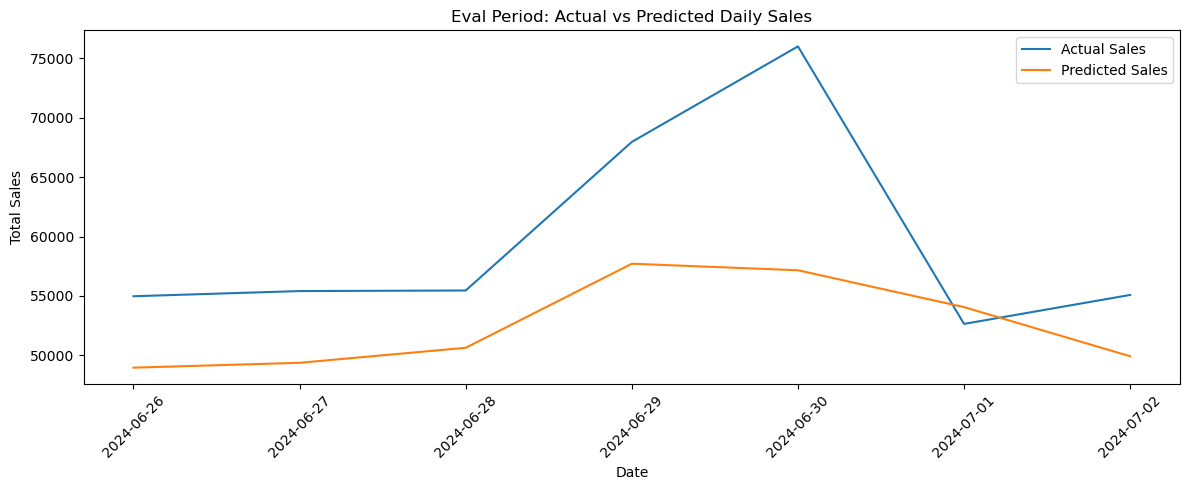

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    eval_daily_summary["dt"],
    eval_daily_summary["total_actual_sales"],
    label="Actual Sales"
)

plt.plot(
    eval_daily_summary["dt"],
    eval_daily_summary["total_predicted_sales"],
    label="Predicted Sales"
)

plt.title("Eval Period: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 14.8 Save Evaluation Forecast Outputs

The evaluation forecast outputs are saved for reporting, Power BI dashboard development, and inventory risk framework creation.

In [101]:
eval_forecast_output.to_csv(
    processed_folder / "eval_forecast_output.csv",
    index=False,
    encoding="utf-8-sig"
)

eval_daily_summary.to_csv(
    processed_folder / "eval_daily_forecast_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

eval_metrics_df = pd.DataFrame([eval_metrics])

eval_metrics_df.to_csv(
    processed_folder / "eval_forecast_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Eval forecast outputs saved successfully.")

Eval forecast outputs saved successfully.


#### 14. Evaluation Forecasting — Result

The evaluation forecasting dataset was prepared successfully using the last 28 days of training history combined with the 7-day evaluation period.

The prepared evaluation dataset contains **350,000 rows**, covering **50,000 product-store combinations** across **7 evaluation days** from **2024-06-26 to 2024-07-02**.

The last 28 days of training data were added before feature engineering to ensure that lag and rolling features such as `sales_lag_28` and `rolling_mean_28` could be calculated correctly. After feature creation, only evaluation-period rows were retained for forecasting.

Feature validation confirmed that all required model features were available and that there were **0 missing values** in the evaluation feature matrix.

The saved final forecasting pipeline was loaded and applied successfully. The final model generated predictions using the stockout-corrected ensemble approach.

The evaluation forecast achieved:

- **MAE:** 0.3618
- **RMSE:** 0.6658
- **WAPE:** 0.3032

The evaluation WAPE was slightly higher than the validation WAPE of approximately **0.2840**, indicating that the future evaluation period was somewhat more difficult to forecast.

Daily analysis showed that the model generally followed the sales pattern but underpredicted several high-demand days. The largest underprediction occurred on **2024-06-30**, where actual sales reached approximately **76,012**, while predicted sales were approximately **57,164**.

Overall, the final saved stockout-corrected ensemble model successfully generated future-period forecasts and achieved reasonable performance on the evaluation period. The main remaining challenge is capturing sharp demand spikes.